<a href="https://colab.research.google.com/github/CikiUmi/airbnb-price-analysis/blob/main/CienciaDeDatos_DHH_ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Carga de la base de datos (de Mongo Atlas a Jupyter)

**Definición del problema y recopilación de datos**    
*  Objetivo del proyecto y las preguntas clave que se buscan responder.

In [ ]:
#Introducción y objetivo del proyecto

'''
Arreglar esto
'''

'\nArreglar esto\n'

**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

In [ ]:
#Importar librerías necesarias para el análisis
from datetime import datetime
import datetime as dt
import time

import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge #1
from sklearn.linear_model import Lasso #2
from sklearn.linear_model import ElasticNet #3
from sklearn.linear_model import RidgeCV #1
from sklearn.linear_model import LassoCV #2
from sklearn.linear_model import ElasticNetCV #3
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm #estadística avanzada
from statsmodels.stats.stattools import durbin_watson
from statsmodels.formula.api import ols
import statsmodels.stats.api as sms #pruebas estadísticas
from statsmodels.compat import lzip

from statsmodels.stats.weightstats import ttest_ind

# Configuración matplotlib
#es como CSS :DDDD
#plt.rcParams['image.cmap'] = "bwr"
#plt.rcParams['figure.dpi'] = "300"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

#para mongo
!pip install pymongo
import pymongo
'''
Ridge -> REGRESIÓN LINEAR CON REGULARIZACIÓN L2 (reduce sobreajuste penalizando coeficientes grandes)
Lasso -> REGRESIÓN LINEAR CON REGULARIZACIÓN L1 (reduce sobreajuste y selección de variables)
ElasticNet -> REGRESIÓN LINEAR CON REGULARIZACIÓN L1 Y L2 (cuando tienes muchas variables es útil)

CV -> CROSS-VALIDATION (nos ayuda a encontrar los mejores valores de penalización (alpha))
      Una suavización mejor. Es como comprobar y eso
'''



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 19.3 MB/s eta 0:00:00


'\nRidge -> REGRESIÓN LINEAR CON REGULARIZACIÓN L2 (reduce sobreajuste penalizando coeficientes grandes)\nLasso -> REGRESIÓN LINEAR CON REGULARIZACIÓN L1 (reduce sobreajuste y selección de variables)\nElasticNet -> REGRESIÓN LINEAR CON REGULARIZACIÓN L1 Y L2 (cuando tienes muchas variables es útil)\n\nCV -> CROSS-VALIDATION (nos ayuda a encontrar los mejores valores de penalización (alpha))\n      Una suavización mejor. Es como comprobar y eso\n'

**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

   **Preparación de los datos:**
*   Carga de datos a MongoAtlas
*   De Mongo se cargan los datos a este cuaderno  

In [ ]:
from google.colab import userdata

#Carga de datos:
MONGO_URI = userdata.get('MONGO_URI') #es la base de datos

client = pymongo.MongoClient(MONGO_URI) #cREA OBJETO cliente para interactuar con MONGO_URI
db = client['airbnb']
collection = db['Propiedades']

documentos = list(collection.find())
df = pd.DataFrame(documentos)

df.head()

,_id,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,680334ed869f76f2e685590e,18224863,4.595120,House,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",8,1.0,Real Bed,strict,...,40.643773,-73.950855,3 Bedroom Apartment for Small Group or Family,Flatbush,5,72.0,https://a0.muscache.com/im/pictures/e9baba99-e...,11226,3.0,3.0
1,680334ed869f76f2e6855919,421056,4.317488,Apartment,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",2,1.0,Real Bed,strict,...,40.661221,-73.948667,"Modern Room in a Cozy, Colorful Apartment",Lefferts Garden,1,100.0,https://a0.muscache.com/im/pictures/34792262-5...,11225,1.0,1.0
2,680334ed869f76f2e685592f,3530517,6.620073,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Pets live on ...",6,2.0,Real Bed,flexible,...,37.730798,-122.448609,Newly Renovated Glen Park Flat,Sunnyside,18,97.0,https://a0.muscache.com/im/pictures/fdfb3056-3...,94127,3.0,3.0
3,680334ed869f76f2e685595b,4576821,4.248495,Apartment,Entire home/apt,"{""Wireless Internet"",Kitchen,Breakfast,Elevato...",1,1.0,Real Bed,flexible,...,40.669026,-73.977079,Charming Studio in Park Slope,Park Slope,2,100.0,https://a0.muscache.com/im/pictures/6666b75f-4...,NaN,0.0,1.0
4,680334ed869f76f2e685595f,14873270,4.174387,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",2,1.0,Real Bed,flexible,...,40.864645,-73.927679,Light Filled Studio Apartment,Washington Heights,5,80.0,https://a0.muscache.com/im/pictures/95725724/2...,10040,0.0,1.0


# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Preparación y Exploración

**Creación de diccionario**


*   Variables con nombres legibles
*   Agrupación por datos similares


In [ ]:
df = pd.DataFrame({
    #ID
    '_ID de Propiedad': df['id'],

    #Información de la propiedad
    # == Anuncio
    'Nombre': df['name'],
    'Descripción': df['description'],
    'Precio (logaritmo)': df['log_price'],
    'URL de la Imagen': df['thumbnail_url'],

    # == Caracerísticas generales
    'Tipo de Propiedad': df['property_type'],
    'Tipo de Habitación': df['room_type'],
    'Capacidad de Alojamiento': df['accommodates'],

    # == Detalles de la propiedad
    'Habitaciones (cantidad)': df['bedrooms'],
    'Tipo de Cama': df['bed_type'],
    'Camas (cantidad)': df['beds'],
    'Baños (cantidad)': df['bathrooms'],
    'Amenidades': df['amenities'],

    # == Ubicación
    'Ciudad': df['city'],
    'Vecindario': df['neighbourhood'],
    'Código Postal': df['zipcode'],
    'Latitud': df['latitude'],
    'Longitud': df['longitude'],

    # == Reseñas
    'Número de Reseñas': df['number_of_reviews'],
    'Puntaje Promedio de Reseñas': df['review_scores_rating'],
    'Primera Reseña': df['first_review'],
    'Última Reseña': df['last_review'],

    #Otros
    'Póliza de Cancelación': df['cancellation_policy'],
    'Tarifa por Limpieza': df['cleaning_fee'],
    'Reservable al Instante': df['instant_bookable'],

    #Host
    'Host tiene Foto de Perfil': df['host_has_profile_pic'],
    'Identidad Verificada del Host': df['host_identity_verified'],
    'Tasa de Respuesta del Host': df['host_response_rate'],
    'Host Desde': df['host_since']
    })

df.head()

,_ID de Propiedad,Nombre,Descripción,Precio (logaritmo),URL de la Imagen,Tipo de Propiedad,Tipo de Habitación,Capacidad de Alojamiento,Habitaciones (cantidad),Tipo de Cama,...,Puntaje Promedio de Reseñas,Primera Reseña,Última Reseña,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Host Desde
0,2479317,Dupont 1 bedroom - 1 mile from the White House!,"Our place is a modern, spacious apartment on t...",6.956545,https://a0.muscache.com/im/pictures/a24c135a-0...,Apartment,Entire home/apt,4,1.0,Real Bed,...,NaN,NaN,NaN,moderate,True,False,True,False,NaN,19/05/2015
1,4274462,**NEW*Downtown/Convention/Subway/Beach C130,"An Entire 2 bedroom, 600sqft, apartment w/ 4 t...",4.828314,https://a0.muscache.com/im/pictures/3d35ea0b-e...,Apartment,Entire home/apt,6,2.0,Real Bed,...,100.0,14/09/2017,02/10/2017,strict,True,False,True,True,100%,25/01/2015
2,19135811,Sunny One bed with Private POOL,One bed room for rent in a 2 bed 2 bath house....,5.010635,https://a0.muscache.com/im/pictures/07602ac1-e...,House,Private room,2,1.0,Real Bed,...,NaN,NaN,NaN,flexible,False,False,True,False,NaN,02/05/2016
3,235281,5 QUEEN BEDS / 2 FULL BATHS / SLEEPS 10! Suite...,This place was FULLY remodeled in 2016 for one...,5.293305,https://a0.muscache.com/im/pictures/7c1650ee-5...,Apartment,Entire home/apt,9,2.0,Real Bed,...,96.0,10/06/2016,16/04/2017,strict,True,False,True,True,100%,13/12/2015
4,583490,VINTAGE 1930s Mediteranian Apt. (NOT a party S...,This apartment is charming and wonderful. Beau...,4.955827,https://a0.muscache.com/im/pictures/9ebde7af-0...,Apartment,Entire home/apt,2,1.0,Real Bed,...,100.0,25/03/2017,06/04/2017,strict,True,False,True,True,100%,20/11/2012


**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Preparación de datos:**


*   Descripción básica del dataset
*   Visualización de muestra
*   Información general de la base
*   Tipos de datos por columna
*   Valores faltantes (número por col)
*   Observar las categorías de cada columna
*   Buscar valores duplicados (ID)

In [ ]:
#Descripción antes de limpiar datos
print("\n ========= DESCRIPCIÓN =========")
df.describe()


 ========= DESCRIPCIÓN =========


,_ID de Propiedad,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Latitud,Longitud,Número de Reseñas,Puntaje Promedio de Reseñas
count,7.411100e+04,74111.000000,74111.000000,74020.000000,73980.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000
mean,1.126662e+07,4.782069,3.155146,1.265793,1.710868,1.235263,38.445958,-92.397525,20.900568,94.067365
std,6.081735e+06,0.717394,2.153589,0.852143,1.254142,0.582044,3.080167,21.705322,37.828641,7.836556
min,3.440000e+02,0.000000,1.000000,0.000000,0.000000,0.000000,33.338905,-122.511500,0.000000,20.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,1.000000,1.000000,34.127908,-118.342374,1.000000,92.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,1.000000,1.000000,40.662138,-76.996965,6.000000,96.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,2.000000,1.000000,40.746096,-73.954660,23.000000,100.000000
max,2.123090e+07,7.600402,16.000000,10.000000,18.000000,8.000000,42.390437,-70.985047,605.000000,100.000000


In [ ]:
#muestra del df al azar
print(" ========= MUESTRA DEL DATA FRAME =========")
df.sample()

 ========= MUESTRA DEL DATA FRAME =========


,_ID de Propiedad,Nombre,Descripción,Precio (logaritmo),URL de la Imagen,Tipo de Propiedad,Tipo de Habitación,Capacidad de Alojamiento,Habitaciones (cantidad),Tipo de Cama,...,Puntaje Promedio de Reseñas,Primera Reseña,Última Reseña,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Host Desde
65645,15952368,BEST VIEWS IN MANHATTAN - FAMILY VACATION - PARKS,"Modern, beautiful, hi end, fully furnished new...",5.010635,NaN,Apartment,Entire home/apt,4,2.0,Real Bed,...,NaN,NaN,NaN,flexible,False,False,True,False,100%,12/08/2016


In [ ]:
#Visualización inicial
print(" ========= INFORMACIÓN =========")
df.info()

 ========= INFORMACIÓN =========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   _ID de Propiedad               74111 non-null  int64  
 1   Nombre                         74111 non-null  object 
 2   Descripción                    74111 non-null  object 
 3   Precio (logaritmo)             74111 non-null  float64
 4   URL de la Imagen               65895 non-null  object 
 5   Tipo de Propiedad              74111 non-null  object 
 6   Tipo de Habitación             74111 non-null  object 
 7   Capacidad de Alojamiento       74111 non-null  int64  
 8   Habitaciones (cantidad)        74020 non-null  float64
 9   Tipo de Cama                   74111 non-null  object 
 10  Camas (cantidad)               73980 non-null  float64
 11  Baños (cantidad)               73911 non-null  float64
 12  Amenidades   

In [ ]:
#Valores faltantes
print("\n\n= VALORES DECLARADOS COMO FALTANTES =")
df.isnull().sum()



= VALORES DECLARADOS COMO FALTANTES =


,0
_ID de Propiedad,0
Nombre,0
Descripción,0
Precio (logaritmo),0
URL de la Imagen,8216
Tipo de Propiedad,0
Tipo de Habitación,0
Capacidad de Alojamiento,0
Habitaciones (cantidad),91
Tipo de Cama,0


In [ ]:
#Todas las categorías de las columnas:
print("======= TIPO DE PROPIEDAD ========")
print(df['Tipo de Propiedad'].unique())

print("\n======= TIPO DE HABITACIÓN ========")
print(df['Tipo de Habitación'].unique())

print("\n======= TIPO DE CAMA ========")
print(df['Tipo de Cama'].unique())

print("\n======= CIUDAD ========")
print(df['Ciudad'].unique())

print("\n======= PÓLIZA DE CANCELACIÓN ========")
print(df['Póliza de Cancelación'].unique())

======= TIPO DE PROPIEDAD ========
['Apartment' 'House' 'Condominium' 'Loft' 'Guest suite' 'Townhouse'
 'Hostel' 'Bungalow' 'Bed & Breakfast' 'Dorm' 'Guesthouse' 'Other'
 'Camper/RV' 'Villa' 'Boutique hotel' 'Timeshare' 'Serviced apartment'
 'Boat' 'In-law' 'Castle' 'Cabin' 'Treehouse' 'Tipi' 'Vacation home'
 'Tent' 'Hut' 'Casa particular' 'Chalet' 'Yurt' 'Earth House'
 'Parking Space' 'Train' 'Cave' 'Lighthouse' 'Island']

======= TIPO DE HABITACIÓN ========
['Entire home/apt' 'Private room' 'Shared room']

======= TIPO DE CAMA ========
['Real Bed' 'Futon' 'Pull-out Sofa' 'Couch' 'Airbed']

======= CIUDAD ========
['DC' 'Boston' 'LA' 'Chicago' 'NYC' 'SF']

======= PÓLIZA DE CANCELACIÓN ========
['moderate' 'strict' 'flexible' 'super_strict_30' 'super_strict_60']


In [ ]:
#Valores repetidos
df[df['_ID de Propiedad'].duplicated()]

,_ID de Propiedad,Nombre,Descripción,Precio (logaritmo),URL de la Imagen,Tipo de Propiedad,Tipo de Habitación,Capacidad de Alojamiento,Habitaciones (cantidad),Tipo de Cama,...,Puntaje Promedio de Reseñas,Primera Reseña,Última Reseña,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Host Desde


# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Limpieza y Transformación de datos

**Correcciones**

*   Caracteres especiales
*   Booleanos incorrectos
*   Categorías: Póliza de cancelación  
*   Amenidades

In [ ]:
#datos ¿qué tipo son?
print(" ========= TIPO DE DATOS =========")
print(df.dtypes)

 ========= TIPO DE DATOS =========
_ID de Propiedad                   int64
Nombre                            object
Descripción                       object
Precio (logaritmo)               float64
URL de la Imagen                  object
Tipo de Propiedad                 object
Tipo de Habitación                object
Capacidad de Alojamiento           int64
Habitaciones (cantidad)          float64
Tipo de Cama                      object
Camas (cantidad)                 float64
Baños (cantidad)                 float64
Amenidades                        object
Ciudad                            object
Vecindario                        object
Código Postal                     object
Latitud                          float64
Longitud                         float64
Número de Reseñas                  int64
Puntaje Promedio de Reseñas      float64
Primera Reseña                    object
Última Reseña                     object
Póliza de Cancelación             object
Tarifa por Limpieza   

In [ ]:
#Espacois al principio y final
df['Nombre'] = df['Nombre'].str.strip()
df['Descripción'] = df['Descripción'].str.strip()

#Acentos
acentos = ['á', 'é', 'í', 'ó', 'ú', 'à', 'è', 'ì', 'ò', 'ù', 'â', 'ê', 'î', 'ô', 'û', 'ä', 'ë', 'ï', 'ö', 'ü']
bien = ['a','e','i','o','u','a','e','i','o','u','a','e','i','o','u','a','e','i','o','u']

for i in range(len(acentos)):
  df['Nombre'] = df['Nombre'].str.replace(acentos[i],bien[i], regex =False)
  df['Descripción'] = df['Descripción'].str.replace(acentos[i],bien[i], regex=False)

#otros
borrar = ['ç', 'ñ', 'ø', 'Å', 'Ø', 'ß', 'Ł', 'ł', '€', '£', '¥', '₹', '¿', '¡', 'æ', 'œ', 'Ç', 'µ', '¾', '¶', 'Œ', '¹', 'ˆ', '¤', '§', 'Š', '©', '¦', '¨', '®', '¼']

for i in range(len(borrar)):
  df['Nombre'] = df['Nombre'].str.replace(borrar[i],'', regex=False)
  df['Descripción'] = df['Descripción'].str.replace(borrar[i],'', regex=False)

In [ ]:
#booleanos incorrectos
df['Host tiene Foto de Perfil'] = df['Host tiene Foto de Perfil'].replace({'t': True, 'f': False}, regex =False)
df['Identidad Verificada del Host'] = df['Identidad Verificada del Host'].replace({'t': True, 'f': False}, regex =False)

In [ ]:
#Póliza de cancelación
print("\n======= ANTES DE ARREGLAR: ========")
print(df['Póliza de Cancelación'].unique())

df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace({'super_strict_30':'super strict','super_strict_60':'super strict'}, regex =False)

print("\n======= CATEGORÍAS CORRECTAS ========")
print(df['Póliza de Cancelación'].unique())


======= ANTES DE ARREGLAR: ========
['moderate' 'strict' 'flexible' 'super_strict_30' 'super_strict_60']

======= CATEGORÍAS CORRECTAS ========
['moderate' 'strict' 'flexible' 'super strict']


In [ ]:
df['Amenidades'].head(30)

,Amenidades
0,"{TV,""Wireless Internet"",""Air conditioning"",Kit..."
1,"{TV,""Wireless Internet"",""Air conditioning"",Kit..."
2,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A..."
3,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A..."
4,"{Kitchen,Heating,""Smoke detector"",""Carbon mono..."
5,"{""Wireless Internet"",""Air conditioning"",Kitche..."
6,"{TV,""Wireless Internet"",""Air conditioning"",Kit..."
7,"{TV,Internet,""Wireless Internet"",""Air conditio..."
8,"{TV,""Cable TV"",""Wireless Internet"",""Air condit..."
9,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A..."


In [ ]:
for i in range(0,11):
  print(df['Amenidades'].iloc[i])

{TV,"Wireless Internet","Air conditioning",Kitchen,Heating,Washer,Dryer,"Smoke detector","Fire extinguisher",Essentials,"Lock on bedroom door","Hair dryer",Iron,"translation missing: en.hosting_amenity_49"}
{TV,"Wireless Internet","Air conditioning",Kitchen,Heating,"Smoke detector","Carbon monoxide detector","First aid kit","Safety card","Fire extinguisher",Essentials,Shampoo,Hangers,"Hair dryer",Iron,"Laptop friendly workspace","Hot water","Bed linens",Microwave,"Coffee maker",Refrigerator,"Dishes and silverware","Cooking basics",Oven,Stove,"Long term stays allowed"}
{TV,"Cable TV",Internet,"Wireless Internet","Air conditioning",Pool,Kitchen,"Free parking on premises","Pets live on this property",Dog(s),"Hot tub",Heating,Washer,Dryer,Essentials,Shampoo,Hangers,"Hair dryer","Laptop friendly workspace","translation missing: en.hosting_amenity_49","translation missing: en.hosting_amenity_50"}
{TV,"Cable TV",Internet,"Wireless Internet","Air conditioning",Kitchen,"Free parking on premises

In [ ]:
# === Amenidades
# = coso para agregar otra columna
df['Número de Amenidades'] = df['Amenidades']
contador = 0

# = para ver todas las amenidades que existen:
azul = set(())
for i in range(len(df['Amenidades'])): #por cada fila de amenidades
  listaAmenidades = str(df['Amenidades'].iloc[i]) # Convierte el contenido de la celda en string
  listaAmenidades = listaAmenidades.strip('{}').strip('[]').strip().strip().strip() #Quita corchetes, llaves y espacios B(
  listaAmenidades = listaAmenidades.replace('"','').split(',') #cuando encuentre una coma divide, si hay comillas las quita
  for q in listaAmenidades: #por cada amenidad individual:
    q.strip() #quita espacios
    azul.add(q) #añade la amenidad al set 'azul'
    contador += 1 #cuenta las amenidades
  df.at[i, "Número de Amenidades"] = contador
  contador = 0

  df.at[i, "Amenidades"] = listaAmenidades # El contenido de amenidades se cambia por la lista

df['Amenidades'].head()
print(azul) #todas las amenidades sin duplicados B)

{'', 'Wheelchair accessible', 'Smart lock', 'Wide clearance to shower & toilet', 'Elevator', 'Baby monitor', 'Dryer', 'Wireless Internet', 'Hot water', 'Babysitter recommendations', 'Smoke detector', 'Fire extinguisher', 'Carbon monoxide detector', 'Buzzer/wireless intercom', 'Cable TV', 'Iron', 'Safety card', 'Oven', 'Flat smooth pathway to front door', 'First aid kit', 'Hair dryer', 'Heating', 'Private entrance', 'Childrenâ€™s books and toys', 'Breakfast', 'Dishwasher', 'Accessible-height bed', 'Internet', 'Bathtub', 'Lockbox', 'Stove', 'Paid parking off premises', 'Accessible-height toilet', 'Pocket wifi', 'Hand or paper towel', 'Self Check-In', 'Firm matress', 'Bed linens', 'Flat', 'Indoor fireplace', 'Single level home', 'Elevator in building', 'Coffee maker', 'Washer', 'Smartlock', 'Hot tub', 'Hot water kettle', 'Family/kid friendly', 'Table corner guards', 'Extra pillows and blankets', 'Doorman Entry', 'Hand soap', 'Private bathroom', 'Long term stays allowed', 'Pool', 'Private 

In [ ]:
df['Amenidades'].head()

,Amenidades
0,"[TV, Wireless Internet, Air conditioning, Kitc..."
1,"[TV, Wireless Internet, Air conditioning, Kitc..."
2,"[TV, Cable TV, Internet, Wireless Internet, Ai..."
3,"[TV, Cable TV, Internet, Wireless Internet, Ai..."
4,"[Kitchen, Heating, Smoke detector, Carbon mono..."


In [ ]:
df['Número de Amenidades'].head()

,Número de Amenidades
0,14
1,26
2,21
3,23
4,7


In [ ]:
for i in range(0,11):
  print(df['Amenidades'].iloc[i])

['TV', 'Wireless Internet', 'Air conditioning', 'Kitchen', 'Heating', 'Washer', 'Dryer', 'Smoke detector', 'Fire extinguisher', 'Essentials', 'Lock on bedroom door', 'Hair dryer', 'Iron', 'translation missing: en.hosting_amenity_49']
['TV', 'Wireless Internet', 'Air conditioning', 'Kitchen', 'Heating', 'Smoke detector', 'Carbon monoxide detector', 'First aid kit', 'Safety card', 'Fire extinguisher', 'Essentials', 'Shampoo', 'Hangers', 'Hair dryer', 'Iron', 'Laptop friendly workspace', 'Hot water', 'Bed linens', 'Microwave', 'Coffee maker', 'Refrigerator', 'Dishes and silverware', 'Cooking basics', 'Oven', 'Stove', 'Long term stays allowed']
['TV', 'Cable TV', 'Internet', 'Wireless Internet', 'Air conditioning', 'Pool', 'Kitchen', 'Free parking on premises', 'Pets live on this property', 'Dog(s)', 'Hot tub', 'Heating', 'Washer', 'Dryer', 'Essentials', 'Shampoo', 'Hangers', 'Hair dryer', 'Laptop friendly workspace', 'translation missing: en.hosting_amenity_49', 'translation missing: en.h

In [ ]:
queso = 0
for i in azul:
  print(i)
  queso += 1
print(queso)


Wheelchair accessible
Smart lock
Wide clearance to shower & toilet
Elevator
Baby monitor
Dryer
Wireless Internet
Hot water
Babysitter recommendations
Smoke detector
Fire extinguisher
Carbon monoxide detector
Buzzer/wireless intercom
Cable TV
Iron
Safety card
Oven
Flat smooth pathway to front door
First aid kit
Hair dryer
Heating
Private entrance
Childrenâ€™s books and toys
Breakfast
Dishwasher
Accessible-height bed
Internet
Bathtub
Lockbox
Stove
Paid parking off premises
Accessible-height toilet
Pocket wifi
Hand or paper towel
Self Check-In
Firm matress
Bed linens
Flat
Indoor fireplace
Single level home
Elevator in building
Coffee maker
Washer
Smartlock
Hot tub
Hot water kettle
Family/kid friendly
Table corner guards
Extra pillows and blankets
Doorman Entry
Hand soap
Private bathroom
Long term stays allowed
Pool
Private living room
Handheld shower head
Doorman
translation missing: en.hosting_amenity_50
translation missing: en.hosting_amenity_49
Game console
 smooth pathway to front do

In [ ]:
#Arreglar formato y eso

# == mayúsculas
#for j in range(0,6):
for j in range(len(df['Amenidades'])):
   # print(df['Amenidades'].iloc[j])
    lista = df['Amenidades'].iloc[j]
    for i in range(len(lista)):
      # == mayúsculas
    #  print(lista[i])
      lista[i] = lista[i].replace(' smooth pathway to','Smooth pathway to')
    #  lista[i] = lista[i].replace('TV','Pizza')

      # == traducción
      lista[i] = lista[i].replace('translation missing: en.hosting_amenity_50', '')
      lista[i] = lista[i].replace('translation missing: en.hosting_amenity_49', '')

      # == caracteres extraños
      lista[i] = lista[i].replace('Pack â€™n Play/travel crib', 'Pack and Play/travel crib')
      lista[i] = lista[i].replace('Childrenâ€™s books and toys', 'Children\'s books and toys')
      lista[i] = lista[i].replace('Childrenâ€™s dinnerware', 'Children\'s dinnerware')

      # == mismo significado
      lista[i] = lista[i].replace('Fixed grab bars for shower & toilet', 'Grab-rails for shower and toilet')

In [ ]:
for j in range(len(df['Amenidades'])):  #por todas las filas en Amenidades
   # print(df['Amenidades'].iloc[j])
    lista = df['Amenidades'].iloc[j]  # Lista = el contenido de la celda (que es una lista)
    lista = [i for i in lista if i != ''] # Lista = a la lista sin los strings vacíos
    df.at[j, "Amenidades"] = lista # La celda ahora tiene la lista sin los cosos vacíos

for i in range(0,11):
  print(df['Amenidades'].iloc[i])

['TV', 'Wireless Internet', 'Air conditioning', 'Kitchen', 'Heating', 'Washer', 'Dryer', 'Smoke detector', 'Fire extinguisher', 'Essentials', 'Lock on bedroom door', 'Hair dryer', 'Iron']
['TV', 'Wireless Internet', 'Air conditioning', 'Kitchen', 'Heating', 'Smoke detector', 'Carbon monoxide detector', 'First aid kit', 'Safety card', 'Fire extinguisher', 'Essentials', 'Shampoo', 'Hangers', 'Hair dryer', 'Iron', 'Laptop friendly workspace', 'Hot water', 'Bed linens', 'Microwave', 'Coffee maker', 'Refrigerator', 'Dishes and silverware', 'Cooking basics', 'Oven', 'Stove', 'Long term stays allowed']
['TV', 'Cable TV', 'Internet', 'Wireless Internet', 'Air conditioning', 'Pool', 'Kitchen', 'Free parking on premises', 'Pets live on this property', 'Dog(s)', 'Hot tub', 'Heating', 'Washer', 'Dryer', 'Essentials', 'Shampoo', 'Hangers', 'Hair dryer', 'Laptop friendly workspace']
['TV', 'Cable TV', 'Internet', 'Wireless Internet', 'Air conditioning', 'Kitchen', 'Free parking on premises', 'Buzzer

In [ ]:
df.head()

,_ID de Propiedad,Nombre,Descripción,Precio (logaritmo),URL de la Imagen,Tipo de Propiedad,Tipo de Habitación,Capacidad de Alojamiento,Habitaciones (cantidad),Tipo de Cama,...,Primera Reseña,Última Reseña,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Host Desde,Número de Amenidades
0,2479317,Dupont 1 bedroom - 1 mile from the White House!,"Our place is a modern, spacious apartment on t...",6.956545,https://a0.muscache.com/im/pictures/a24c135a-0...,Apartment,Entire home/apt,4,1.0,Real Bed,...,NaN,NaN,moderate,True,False,True,False,NaN,19/05/2015,14
1,4274462,**NEW*Downtown/Convention/Subway/Beach C130,"An Entire 2 bedroom, 600sqft, apartment w/ 4 t...",4.828314,https://a0.muscache.com/im/pictures/3d35ea0b-e...,Apartment,Entire home/apt,6,2.0,Real Bed,...,14/09/2017,02/10/2017,strict,True,False,True,True,100%,25/01/2015,26
2,19135811,Sunny One bed with Private POOL,One bed room for rent in a 2 bed 2 bath house....,5.010635,https://a0.muscache.com/im/pictures/07602ac1-e...,House,Private room,2,1.0,Real Bed,...,NaN,NaN,flexible,False,False,True,False,NaN,02/05/2016,21
3,235281,5 QUEEN BEDS / 2 FULL BATHS / SLEEPS 10! Suite...,This place was FULLY remodeled in 2016 for one...,5.293305,https://a0.muscache.com/im/pictures/7c1650ee-5...,Apartment,Entire home/apt,9,2.0,Real Bed,...,10/06/2016,16/04/2017,strict,True,False,True,True,100%,13/12/2015,23
4,583490,VINTAGE 1930s Mediteranian Apt. (NOT a party S...,This apartment is charming and wonderful. Beau...,4.955827,https://a0.muscache.com/im/pictures/9ebde7af-0...,Apartment,Entire home/apt,2,1.0,Real Bed,...,25/03/2017,06/04/2017,strict,True,False,True,True,100%,20/11/2012,7


**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Transformación de datos (formatos)**


*   Fechas
*   Categorías (espacios y mayús en la de póliza)
*   Decimales
*   Porcentajes
*   Tipos de datos





In [ ]:
# Conversión a tipo fecha
df['Primera Reseña'] = pd.to_datetime(df['Primera Reseña'], format='%d/%m/%Y')
df['Última Reseña'] = pd.to_datetime(df['Última Reseña'], format='%d/%m/%Y')
df['Host Desde'] = pd.to_datetime(df['Host Desde'], format='%d/%m/%Y')

df[['Primera Reseña','Última Reseña','Host Desde']].head()

,Primera Reseña,Última Reseña,Host Desde
0,NaT,NaT,2015-05-19
1,2017-09-14,2017-10-02,2015-01-25
2,NaT,NaT,2016-05-02
3,2016-06-10,2017-04-16,2015-12-13
4,2017-03-25,2017-04-06,2012-11-20


In [ ]:
#Categorías
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('super strict','Super strict', regex =False)
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('strict','Strict', regex =False)
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('flexible','Flexible', regex =False)
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('moderate','Moderate', regex =False)

df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('Super strict', 4,regex =False)
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('Strict',3, regex =False)
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('Flexible',2, regex =False)
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].replace('Moderate',1, regex =False)

print("\n======= PÓLIZA DE CANCELACIÓN ========")
print(df['Póliza de Cancelación'].unique())


======= PÓLIZA DE CANCELACIÓN ========
[1 3 2 4]


In [ ]:
#Decimales

 # == Precio
for i in range(len(df['Precio (logaritmo)'])): #por cada fila en precio
  try:
    decimales = f"{(df['Precio (logaritmo)'].iloc[i]):.10f}" #da formato de 10 decimales a la celda i
    df.at[i, "Precio (logaritmo)"] = np.float64(decimales) #lo asigna como tipo decimal
  except Exception as e:
    continue

 # == Latitud
for i in range(len(df['Latitud'])):
  try:
    decimales = f"{(df['Latitud'].iloc[i]):.10f}"
    df.at[i, "Latitud"] = np.float64(decimales)
  except Exception as e:
    continue

 # == Longitud
for i in range(len(df['Longitud'])):
  try:
    decimales = f"{(df['Longitud'].iloc[i]):.10f}"
    df.at[i, "Longitud"] = np.float64(decimales)
  except Exception as e:
    continue

df[['Precio (logaritmo)','Latitud','Longitud',]].head()

,Precio (logaritmo),Latitud,Longitud
0,6.956545,38.911275,-77.037272
1,4.828314,42.336007,-71.052918
2,5.010635,34.079793,-118.345951
3,5.293305,41.933496,-87.658119
4,4.955827,33.778526,-118.145926


In [ ]:
#Porcentajes
for i in range(len(df['Tasa de Respuesta del Host'])):
  try:
    porcentaje = np.float64(df['Tasa de Respuesta del Host'].iloc[i].strip('%'))/100
    poecentaje = f"{(porcentaje):.2f}"
    df.at[i, "Tasa de Respuesta del Host"] = np.float64(porcentaje)
  except Exception as e:
    continue

df['Tasa de Respuesta del Host'].head()

,Tasa de Respuesta del Host
0,NaN
1,1.0
2,NaN
3,1.0
4,1.0


In [ ]:
#Otros datos que deben arreglarse

  # == Strings
df['Nombre'] = df['Nombre'].astype('string')
df['Descripción'] = df['Descripción'].astype('string')
df['_ID de Propiedad'] = df['_ID de Propiedad'].astype('string')
df['Código Postal'] = df['Código Postal'].astype('string')
df['Latitud'] = df['Latitud'].astype('string')
df['Longitud'] = df['Longitud'].astype('string')

  # == Categorías
df['Tipo de Propiedad'] = df['Tipo de Propiedad'].astype('category')
df['Tipo de Habitación'] = df['Tipo de Habitación'].astype('category')
df['Tipo de Cama'] = df['Tipo de Cama'].astype('category')
df['Ciudad'] = df['Ciudad'].astype('category')
df['Vecindario'] = df['Vecindario'].astype('category')
df['Póliza de Cancelación'] = df['Póliza de Cancelación'].astype('int64')

  # == Booleanos
df['Host tiene Foto de Perfil'] = df['Host tiene Foto de Perfil'].astype('bool')
df['Identidad Verificada del Host'] = df['Identidad Verificada del Host'].astype('bool')

 # == Números
df['Tasa de Respuesta del Host'] = df['Tasa de Respuesta del Host'].astype('float64')
df['Número de Amenidades'] = df['Número de Amenidades'].astype('int64')

In [ ]:
for i in df.select_dtypes('bool'):
  df[i] = df[i].replace({True: 1, False:0}, regex =False)
  df[i] = df[i].astype('float64')

In [ ]:
df['Núm. Caracteres en Descripción'] = df['Descripción'].str.len()
df['Núm. Caracteres en Nombre'] = df['Nombre'].str.len()

df['Núm. Caracteres en Descripción'] = df['Núm. Caracteres en Descripción'].astype('float64')
df['Núm. Caracteres en Nombre'] = df['Núm. Caracteres en Nombre'].astype('float64')
#print(df['Nombre'].iloc[0])
#print(df['Descripción'].iloc[0])

In [ ]:
#Enteros
  # == Cantidad de Habitaciones
for i in range(len(df['Habitaciones (cantidad)'])):
  try:
    if df['Habitaciones (cantidad)'].iloc[i].np.isdtype('float64'):
      print(df['Habitaciones (cantidad)'].iloc[i])
    num = f"{(df['Habitaciones (cantidad)'].iloc[i]):.0f}"
    df.at[i, "Habitaciones (cantidad)"] = np.int64(num)
  except Exception as e:
    continue

df['Habitaciones (cantidad)'].head()
  # == Cantidad de Baños
  # == Cantidad de Camas

,Habitaciones (cantidad)
0,1.0
1,2.0
2,1.0
3,2.0
4,1.0


In [ ]:
#Tipos nuevos
print("      ========= TIPO DE DATOS =========")
print(df.dtypes)

      ========= TIPO DE DATOS =========
_ID de Propiedad                  string[python]
Nombre                            string[python]
Descripción                       string[python]
Precio (logaritmo)                       float64
URL de la Imagen                          object
Tipo de Propiedad                       category
Tipo de Habitación                      category
Capacidad de Alojamiento                   int64
Habitaciones (cantidad)                  float64
Tipo de Cama                            category
Camas (cantidad)                         float64
Baños (cantidad)                         float64
Amenidades                                object
Ciudad                                  category
Vecindario                              category
Código Postal                     string[python]
Latitud                           string[python]
Longitud                          string[python]
Número de Reseñas                          int64
Puntaje Promedio de Reseñas  

**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Base de datos lista para el análisis!!**



In [ ]:
df.sample()

,_ID de Propiedad,Nombre,Descripción,Precio (logaritmo),URL de la Imagen,Tipo de Propiedad,Tipo de Habitación,Capacidad de Alojamiento,Habitaciones (cantidad),Tipo de Cama,...,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Host Desde,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
43826,1836467,Lrg 2 bdrm 2 lvrm apt in Manhattan!,Spacious 2 bdrm apt with bdrms at opposite end...,5.438079,https://a0.muscache.com/im/pictures/5183470a-9...,Apartment,Entire home/apt,8,2.0,Real Bed,...,3,1.0,0.0,1.0,1.0,1.0,2015-06-07,25,999.0,35.0


In [ ]:
df.head(6).T

,0,1,2,3,4,5
_ID de Propiedad,2479317,4274462,19135811,235281,583490,5520582
Nombre,Dupont 1 bedroom - 1 mile from the White House!,**NEW*Downtown/Convention/Subway/Beach C130,Sunny One bed with Private POOL,5 QUEEN BEDS / 2 FULL BATHS / SLEEPS 10! Suite...,VINTAGE 1930s Mediteranian Apt. (NOT a party S...,Cosy private room/bathroom in Miracle Mile.
Descripción,"Our place is a modern, spacious apartment on t...","An Entire 2 bedroom, 600sqft, apartment w/ 4 t...",One bed room for rent in a 2 bed 2 bath house....,This place was FULLY remodeled in 2016 for one...,This apartment is charming and wonderful. Beau...,Our place is fully renovated with a nice and c...
Precio (logaritmo),6.956545,4.828314,5.010635,5.293305,4.955827,3.828641
URL de la Imagen,https://a0.muscache.com/im/pictures/a24c135a-0...,https://a0.muscache.com/im/pictures/3d35ea0b-e...,https://a0.muscache.com/im/pictures/07602ac1-e...,https://a0.muscache.com/im/pictures/7c1650ee-5...,https://a0.muscache.com/im/pictures/9ebde7af-0...,https://a0.muscache.com/im/pictures/14bf8357-c...
Tipo de Propiedad,Apartment,Apartment,House,Apartment,Apartment,Apartment
Tipo de Habitación,Entire home/apt,Entire home/apt,Private room,Entire home/apt,Entire home/apt,Private room
Capacidad de Alojamiento,4,6,2,9,2,2
Habitaciones (cantidad),1.0,2.0,1.0,2.0,1.0,1.0
Tipo de Cama,Real Bed,Real Bed,Real Bed,Real Bed,Real Bed,Real Bed


# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Análisis Descriptivo


**Análisis exploratorio de datos:**
*   Utiliza Pandas y NumPy para realizar análisis numérico y manipulación de datos.
*   Explora la distribución de datos numéricos y categóricos mediante el uso de estadísticas descriptivas como media, mediana, moda, etcétera.
*   Crea un resumen estadístico utilizando un DataFrame de Python y sus librerías requeridas, como lo son NumPy y Pandas.
*   Realiza la interpretación del análisis exploratorio.

In [ ]:
dfNoBinario = df.drop(columns=['Tarifa por Limpieza','Reservable al Instante','Host tiene Foto de Perfil','Identidad Verificada del Host'])
dfNoBinario.describe()

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Primera Reseña,Última Reseña,Póliza de Cancelación,Tasa de Respuesta del Host,Host Desde,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
count,74111.000000,74111.000000,74020.000000,73980.000000,73911.000000,74111.000000,57389.000000,58247,58284,74111.000000,55812.000000,73923,74111.000000,74110.000000,74101.000000
mean,4.782069,3.155146,1.265793,1.710868,1.235263,20.900568,94.067365,2016-01-14 08:11:51.013442560,2017-03-14 19:27:18.789376256,2.183090,0.943520,2014-07-21 01:55:09.849437952,17.602407,764.835866,34.988367
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20.000000,2008-11-17 00:00:00,2009-01-21 00:00:00,1.000000,0.000000,2008-03-03 00:00:00,1.000000,1.000000,1.000000
25%,4.317488,2.000000,1.000000,1.000000,1.000000,1.000000,92.000000,2015-06-28 00:00:00,2017-01-09 00:00:00,1.000000,1.000000,2013-04-21 00:00:00,13.000000,484.000000,30.000000
50%,4.709530,2.000000,1.000000,1.000000,1.000000,6.000000,96.000000,2016-05-25 00:00:00,2017-04-28 00:00:00,2.000000,1.000000,2014-09-28 00:00:00,17.000000,999.000000,34.000000
75%,5.220356,4.000000,1.000000,2.000000,1.000000,23.000000,100.000000,2017-01-02 00:00:00,2017-09-08 00:00:00,3.000000,1.000000,2015-12-22 00:00:00,22.000000,1000.000000,43.000000
max,7.600402,16.000000,10.000000,18.000000,8.000000,605.000000,100.000000,2017-10-05 00:00:00,2017-10-05 00:00:00,4.000000,1.000000,2017-10-04 00:00:00,86.000000,2299.000000,179.000000
std,0.717394,2.153589,0.852143,1.254142,0.582044,37.828641,7.836556,NaN,NaN,0.817009,0.163418,NaN,6.936947,316.980499,9.519958


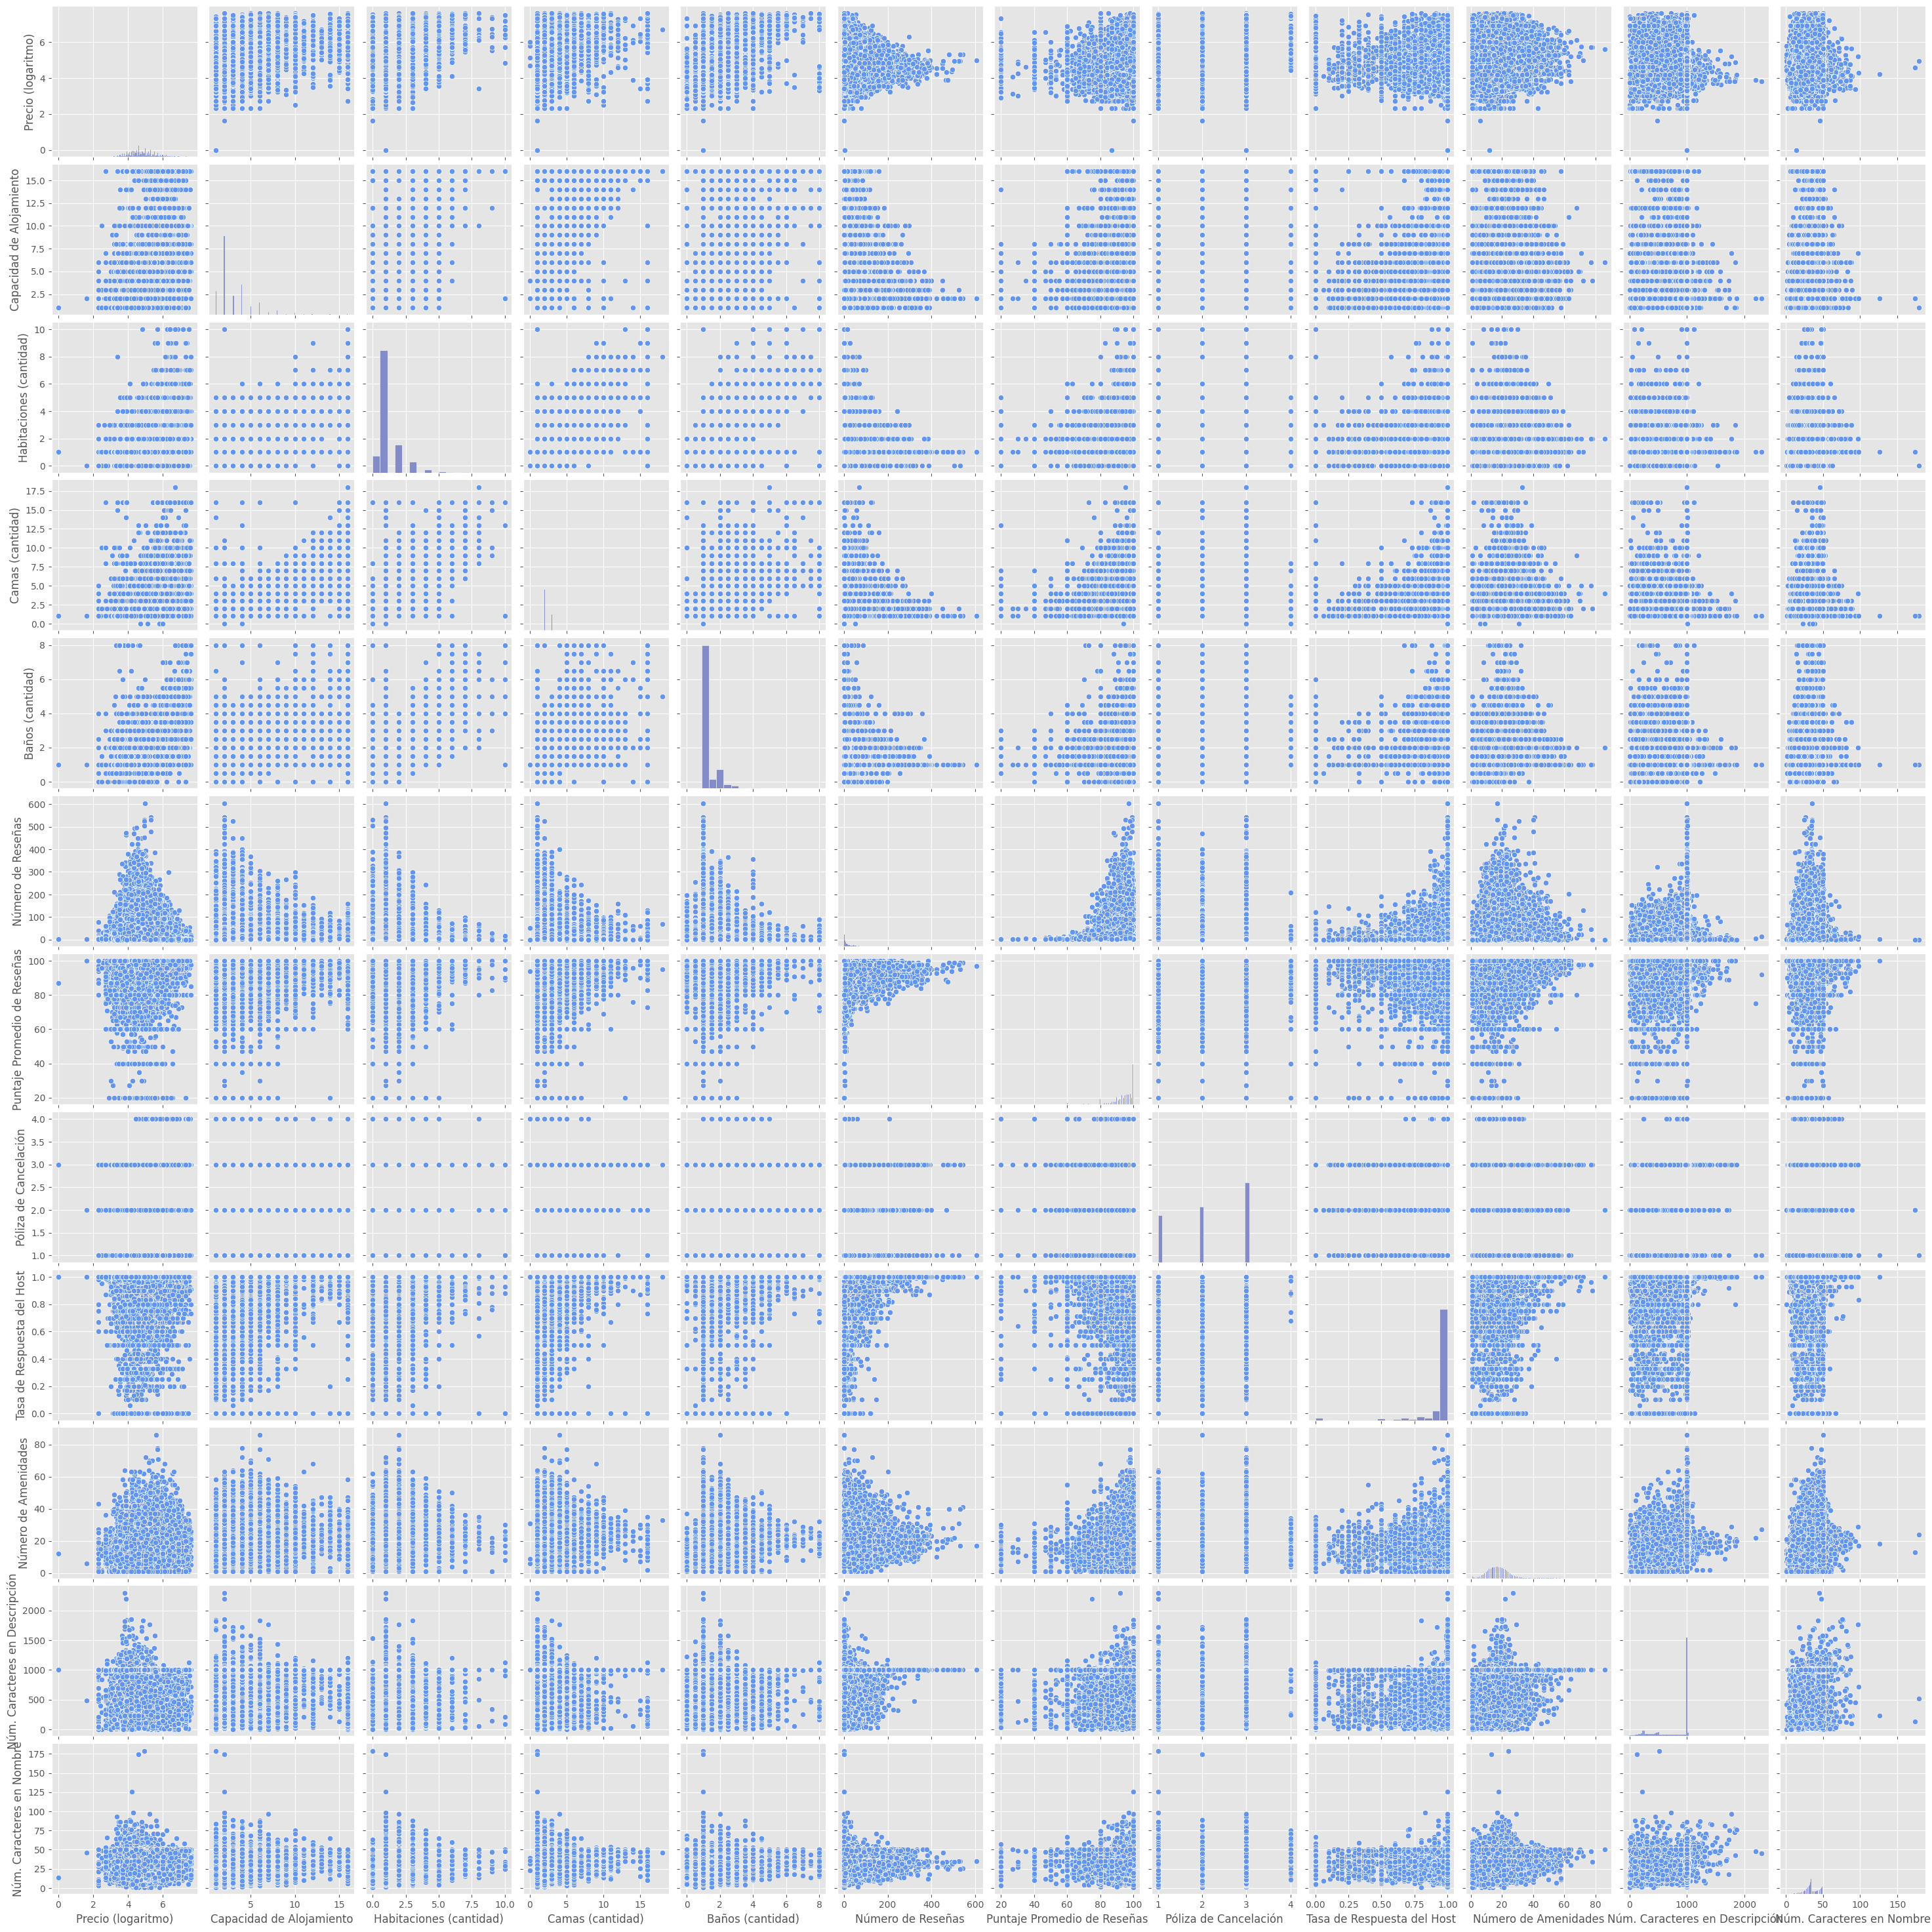

In [ ]:
#Mapa paiplot thingy
pairplotNB = sns.pairplot(dfNoBinario)
pairplotNB.map_upper(sns.scatterplot, color='cornflowerblue')
pairplotNB.map_lower(sns.scatterplot, color='cornflowerblue')
pairplotNB.map_diag(sns.histplot, color='cornflowerblue')
plt.show()

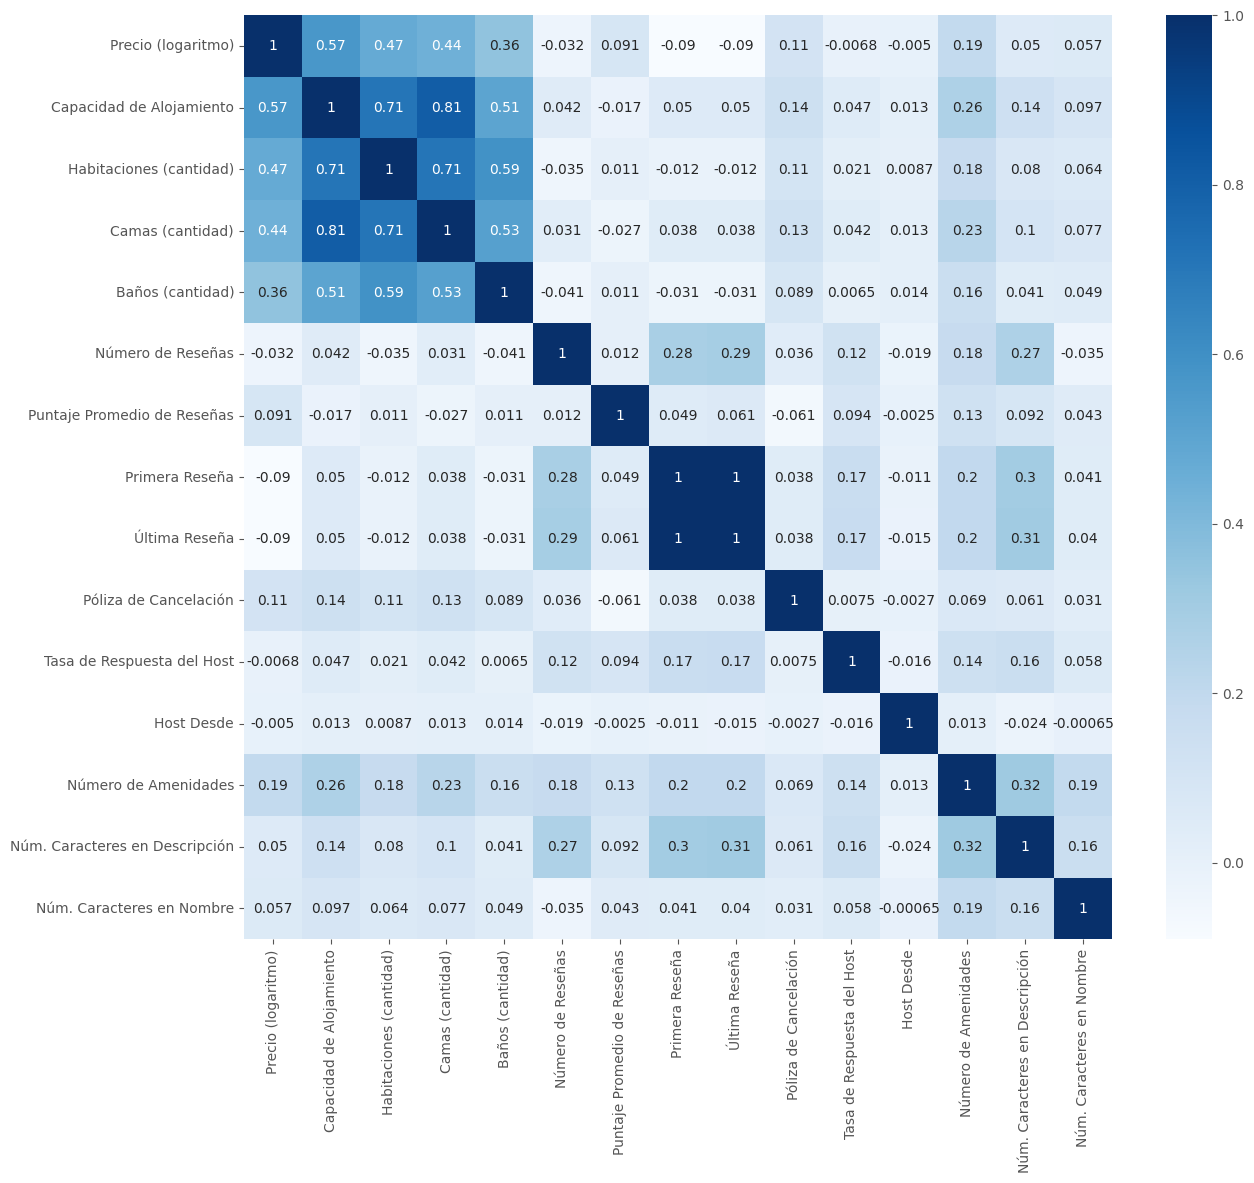

In [ ]:
dfNoBinario = dfNoBinario.drop(columns=df.select_dtypes(include=['string']))
dfNoBinario = dfNoBinario.drop(columns=df.select_dtypes(include=['object']))
dfNoBinario = dfNoBinario.drop(columns=df.select_dtypes(include=['category']))

plt.figure(figsize=(14,12))
sns.heatmap(dfNoBinario.corr(method= "pearson"), annot=True, cmap='Blues')
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
dfBinario = df[['Tarifa por Limpieza','Reservable al Instante','Host tiene Foto de Perfil','Identidad Verificada del Host']]
dfBinario.describe()

,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host
count,74111.000000,74111.000000,74111.000000,74111.000000
mean,0.734075,0.262458,0.996951,0.673800
std,0.441828,0.439973,0.055138,0.468825
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000
50%,1.000000,0.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


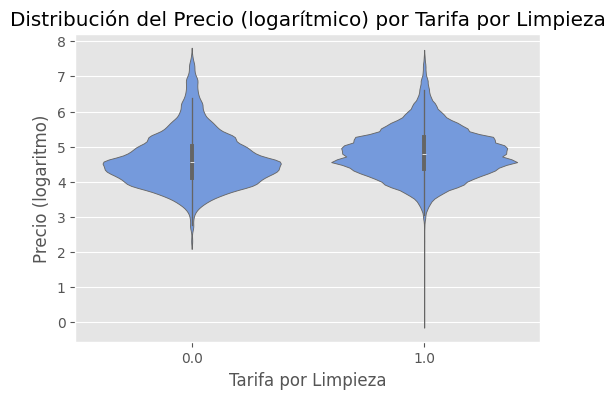

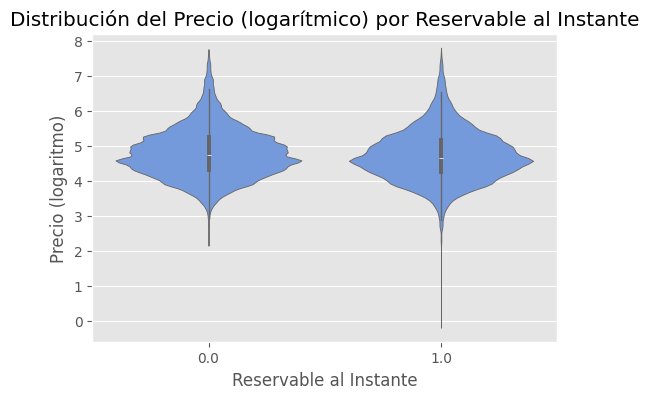

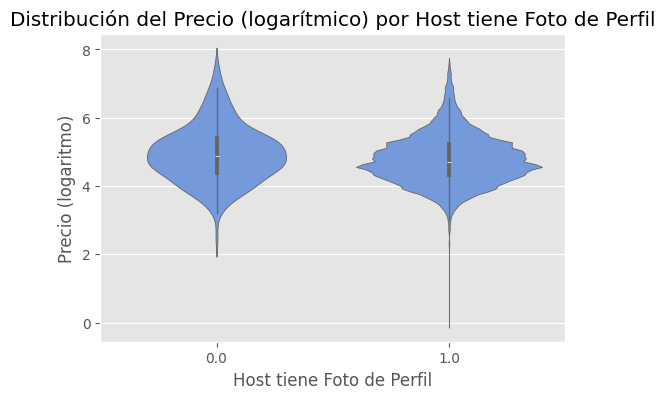

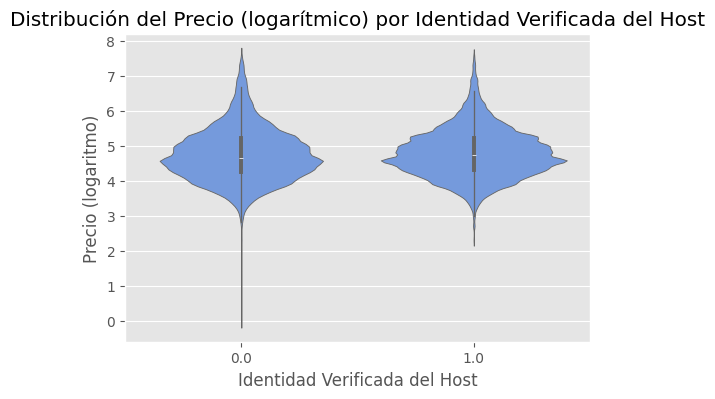

In [ ]:
for i in dfBinario:
    # Gráfico Edad
  fig, ax = plt.subplots(figsize=(6, 4))
  sns.violinplot(
          x     = i,
          y     = 'Precio (logaritmo)',
          data  = df,
          ax    = ax,
          color = 'cornflowerblue'

      )
  ax.set_title(f'Distribución del Precio (logarítmico) por {i}')

In [ ]:
for i in dfBinario:
  #PRUEBA T:
  print(f' == {i.upper()} ==')
  res_ttest = ttest_ind(
                x1 = df['Precio (logaritmo)'][df[i] == 0],
                x2 = df['Precio (logaritmo)'][df[i] == 1],
                alternative='two-sided'
            )
  print(f"t = {res_ttest[0]}\np-value = {res_ttest[1]}")
  print()

 == TARIFA POR LIMPIEZA ==
t = -30.45822643479867
p-value = 1.6697453179808287e-202

 == RESERVABLE AL INSTANTE ==
t = 12.063784599691989
p-value = 1.7637405319154012e-33

 == HOST TIENE FOTO DE PERFIL ==
t = 3.585895174649407
p-value = 0.0003361397594721135

 == IDENTIDAD VERIFICADA DEL HOST ==
t = -6.5392594551577785
p-value = 6.22243555621336e-11



In [ ]:
df.describe()

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Primera Reseña,Última Reseña,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Host Desde,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
count,74111.000000,74111.000000,74020.000000,73980.000000,73911.000000,74111.000000,57389.000000,58247,58284,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,55812.000000,73923,74111.000000,74110.000000,74101.000000
mean,4.782069,3.155146,1.265793,1.710868,1.235263,20.900568,94.067365,2016-01-14 08:11:51.013442560,2017-03-14 19:27:18.789376256,2.183090,0.734075,0.262458,0.996951,0.673800,0.943520,2014-07-21 01:55:09.849437952,17.602407,764.835866,34.988367
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20.000000,2008-11-17 00:00:00,2009-01-21 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008-03-03 00:00:00,1.000000,1.000000,1.000000
25%,4.317488,2.000000,1.000000,1.000000,1.000000,1.000000,92.000000,2015-06-28 00:00:00,2017-01-09 00:00:00,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2013-04-21 00:00:00,13.000000,484.000000,30.000000
50%,4.709530,2.000000,1.000000,1.000000,1.000000,6.000000,96.000000,2016-05-25 00:00:00,2017-04-28 00:00:00,2.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2014-09-28 00:00:00,17.000000,999.000000,34.000000
75%,5.220356,4.000000,1.000000,2.000000,1.000000,23.000000,100.000000,2017-01-02 00:00:00,2017-09-08 00:00:00,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2015-12-22 00:00:00,22.000000,1000.000000,43.000000
max,7.600402,16.000000,10.000000,18.000000,8.000000,605.000000,100.000000,2017-10-05 00:00:00,2017-10-05 00:00:00,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2017-10-04 00:00:00,86.000000,2299.000000,179.000000
std,0.717394,2.153589,0.852143,1.254142,0.582044,37.828641,7.836556,NaN,NaN,0.817009,0.441828,0.439973,0.055138,0.468825,0.163418,NaN,6.936947,316.980499,9.519958


**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

In [ ]:
#df nuevo :3
dfNum = df.drop(columns=df.select_dtypes(include=['string']))
dfNum = dfNum.drop(columns=df.select_dtypes(include=['object']))
dfNum = dfNum.drop(columns=df.select_dtypes(include=['category']))
dfNum = dfNum.drop(columns=df.select_dtypes(include=['datetime64']))

dfNum.head()

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
0,6.956545,4,1.0,2.0,1.0,0,NaN,1,1.0,0.0,1.0,0.0,NaN,14,965.0,47.0
1,4.828314,6,2.0,4.0,1.0,5,100.0,3,1.0,0.0,1.0,1.0,1.0,26,1001.0,43.0
2,5.010635,2,1.0,1.0,1.0,0,NaN,2,0.0,0.0,1.0,0.0,NaN,21,195.0,31.0
3,5.293305,9,2.0,5.0,2.0,10,96.0,3,1.0,0.0,1.0,1.0,1.0,23,1000.0,50.0
4,4.955827,2,1.0,1.0,1.0,2,100.0,3,1.0,0.0,1.0,1.0,1.0,7,999.0,50.0


In [ ]:
#PEARSON
dfNum.corr(method= "pearson")

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
Precio (logaritmo),1.000000,0.567574,0.473212,0.442153,0.355420,-0.032470,0.091219,0.110044,0.111191,-0.044271,-0.013171,0.024014,-0.006777,0.194528,0.050178,0.057041
Capacidad de Alojamiento,0.567574,1.000000,0.709258,0.810801,0.505632,0.041964,-0.017128,0.141843,0.182306,0.053093,-0.003970,0.057689,0.047036,0.264945,0.136743,0.096583
Habitaciones (cantidad),0.473212,0.709258,1.000000,0.709416,0.589935,-0.035149,0.011143,0.105954,0.105454,-0.003654,0.000595,0.025577,0.020566,0.180910,0.079858,0.063788
Camas (cantidad),0.442153,0.810801,0.709416,1.000000,0.525591,0.031109,-0.027330,0.131924,0.131632,0.051354,-0.000262,0.035445,0.041518,0.230607,0.104869,0.077258
Baños (cantidad),0.355420,0.505632,0.589935,0.525591,1.000000,-0.041381,0.010537,0.089143,0.053784,0.001461,-0.003299,0.014222,0.006535,0.160048,0.040853,0.048601
Número de Reseñas,-0.032470,0.041964,-0.035149,0.031109,-0.041381,1.000000,0.011708,0.035505,0.110204,0.077276,0.020362,0.161881,0.123065,0.180768,0.265159,-0.034884
Puntaje Promedio de Reseñas,0.091219,-0.017128,0.011143,-0.027330,0.010537,0.011708,1.000000,-0.061299,0.034879,-0.068874,0.006759,0.055652,0.094395,0.133885,0.091520,0.042521
Póliza de Cancelación,0.110044,0.141843,0.105954,0.131924,0.089143,0.035505,-0.061299,1.000000,0.103332,0.022362,0.004307,0.028894,0.007547,0.069296,0.060815,0.031150
Tarifa por Limpieza,0.111191,0.182306,0.105454,0.131632,0.053784,0.110204,0.034879,0.103332,1.000000,0.010031,0.022654,0.162285,0.117460,0.240181,0.270773,0.093227
Reservable al Instante,-0.044271,0.053093,-0.003654,0.051354,0.001461,0.077276,-0.068874,0.022362,0.010031,1.000000,-0.009280,-0.087729,0.102220,0.100556,-0.015788,0.088344


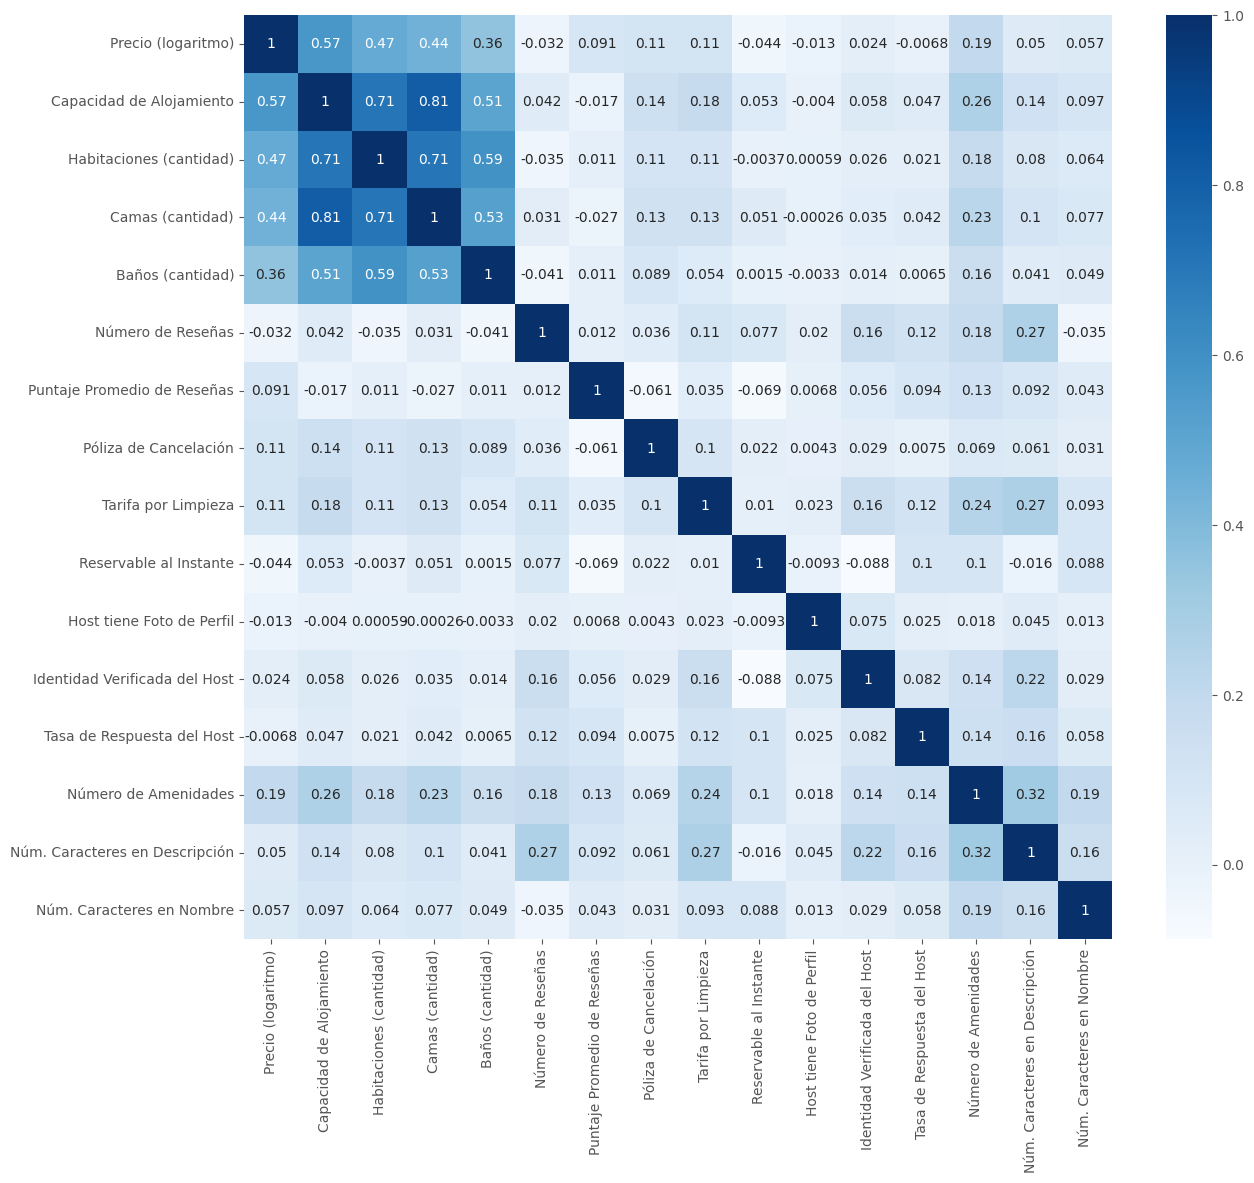

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(dfNum.corr(method= "pearson"), annot=True, cmap='Blues')
plt.show()
#

# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Visualización de Datos

**Creación de gráficas para visualización de datos:**
*   Genera una visualización a través de un diagrama de cajas utilizando Python
*   Crea una gráfica de dispersión para representar la relación entre variables.
*   Crea un histograma para mostrar la distribución de datos.
*   Realiza la interpretación de las gráficas creadas.

*   Mapas de calor para las variables


In [ ]:
dfNum.isnull().sum()

,0
Precio (logaritmo),0
Capacidad de Alojamiento,0
Habitaciones (cantidad),91
Camas (cantidad),131
Baños (cantidad),200
Número de Reseñas,0
Puntaje Promedio de Reseñas,16722
Póliza de Cancelación,0
Tarifa por Limpieza,0
Reservable al Instante,0


In [ ]:
#df = dfNum.drop(columns=['Primera Reseña','Última Reseña'])
for i in dfNum.columns: # IMPUTACIón
  if dfNum[i].isnull().sum() != 0: #por cada columna que no esté completa
    if dfNum[i].dtype == 'float64' or dfNum[i].dtype == 'int64': #si es numérica
      dfNum[i] = dfNum[i].fillna(dfNum[i].media()) #rellena con la media

In [ ]:
dfNum

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
0,6.956545,4,1.0,2.0,1.0,0,96.0,1,1.0,0.0,1.0,0.0,1.0,14,965.0,47.0
1,4.828314,6,2.0,4.0,1.0,5,100.0,3,1.0,0.0,1.0,1.0,1.0,26,1001.0,43.0
2,5.010635,2,1.0,1.0,1.0,0,96.0,2,0.0,0.0,1.0,0.0,1.0,21,195.0,31.0
3,5.293305,9,2.0,5.0,2.0,10,96.0,3,1.0,0.0,1.0,1.0,1.0,23,1000.0,50.0
4,4.955827,2,1.0,1.0,1.0,2,100.0,3,1.0,0.0,1.0,1.0,1.0,7,999.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,5.587249,7,3.0,4.0,3.5,3,87.0,3,1.0,0.0,1.0,1.0,1.0,19,971.0,35.0
74107,3.912023,2,1.0,1.0,1.0,0,96.0,2,0.0,0.0,1.0,1.0,1.0,16,999.0,35.0
74108,4.317488,2,1.0,1.0,1.0,1,60.0,1,1.0,0.0,1.0,1.0,0.9,18,1000.0,30.0
74109,4.941642,3,1.0,2.0,1.0,8,98.0,1,1.0,0.0,1.0,1.0,1.0,32,1000.0,32.0


In [ ]:
dfNum.isnull().sum()

,0
Precio (logaritmo),0
Capacidad de Alojamiento,0
Habitaciones (cantidad),0
Camas (cantidad),0
Baños (cantidad),0
Número de Reseñas,0
Puntaje Promedio de Reseñas,0
Póliza de Cancelación,0
Tarifa por Limpieza,0
Reservable al Instante,0


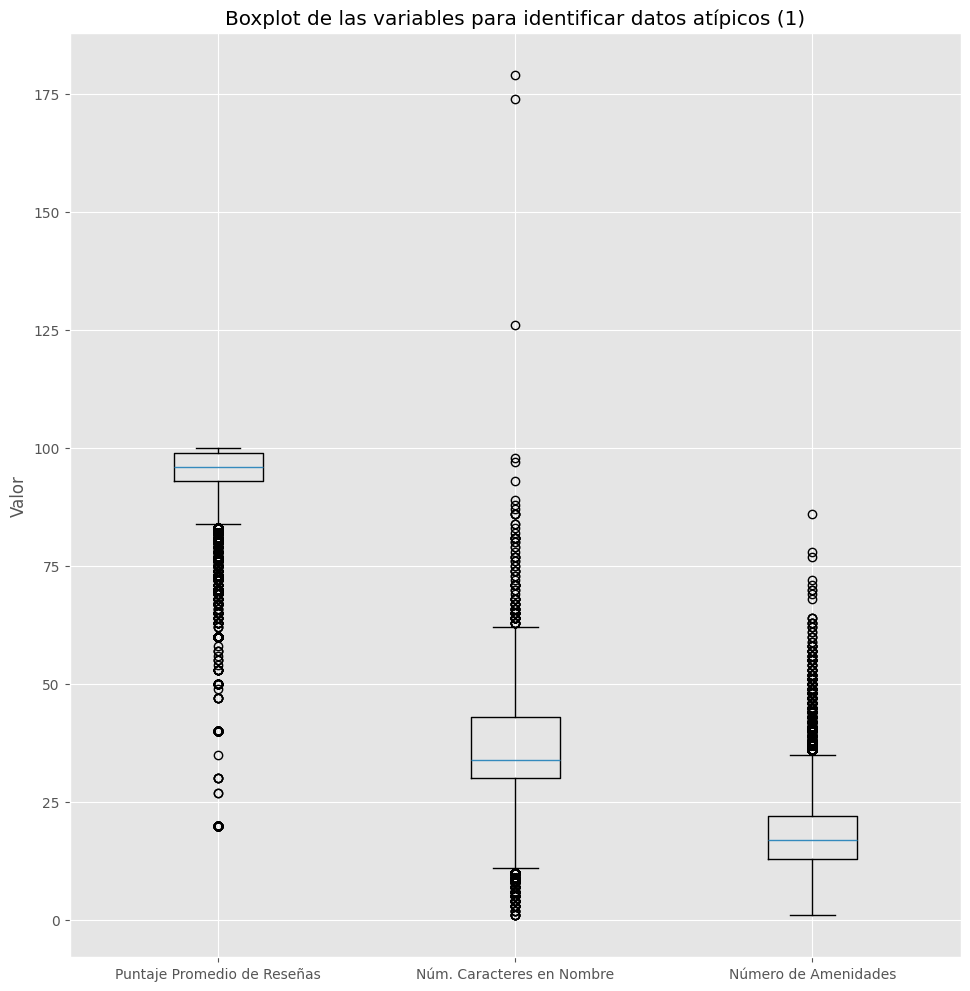

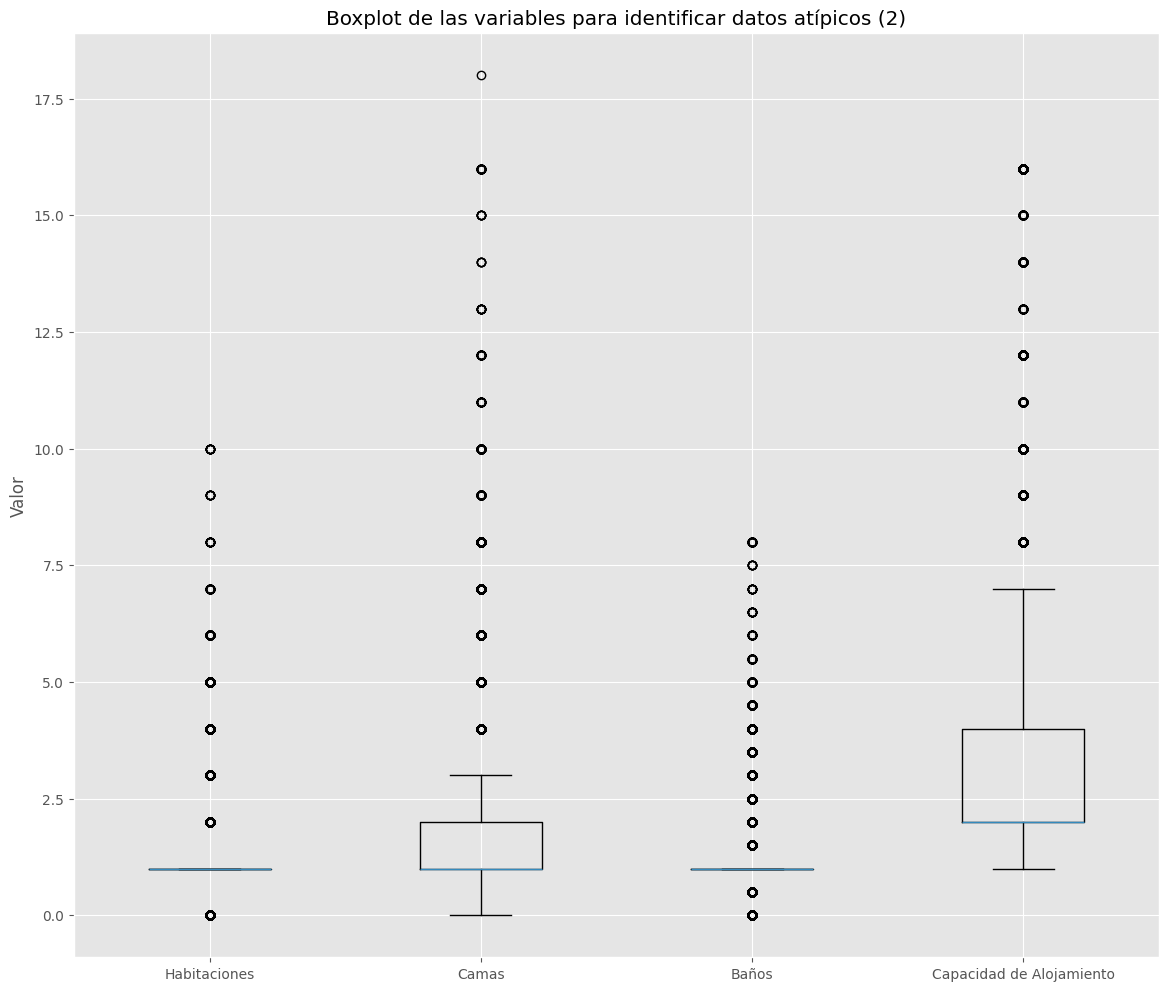

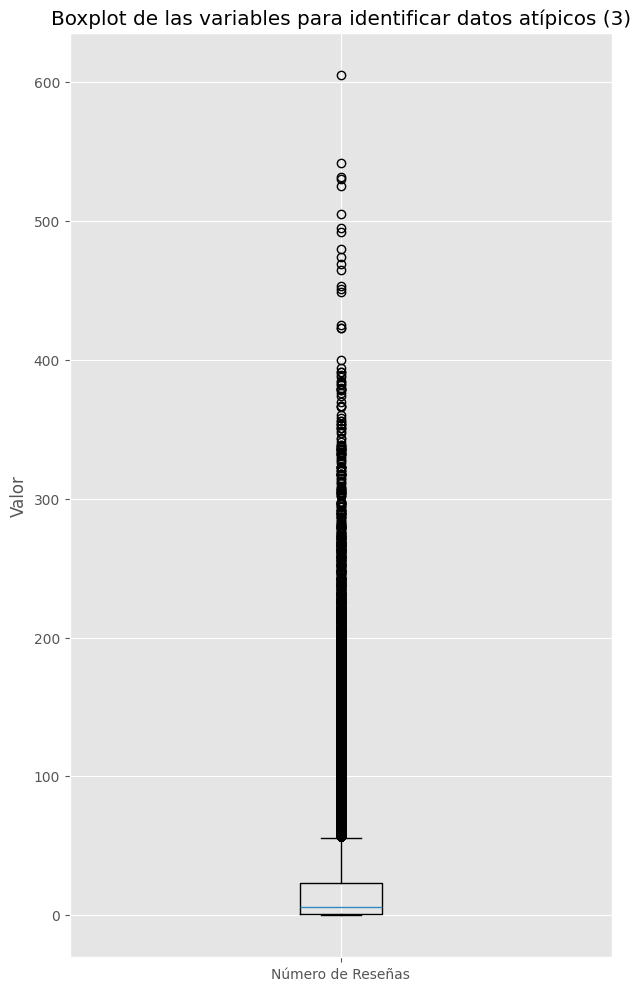

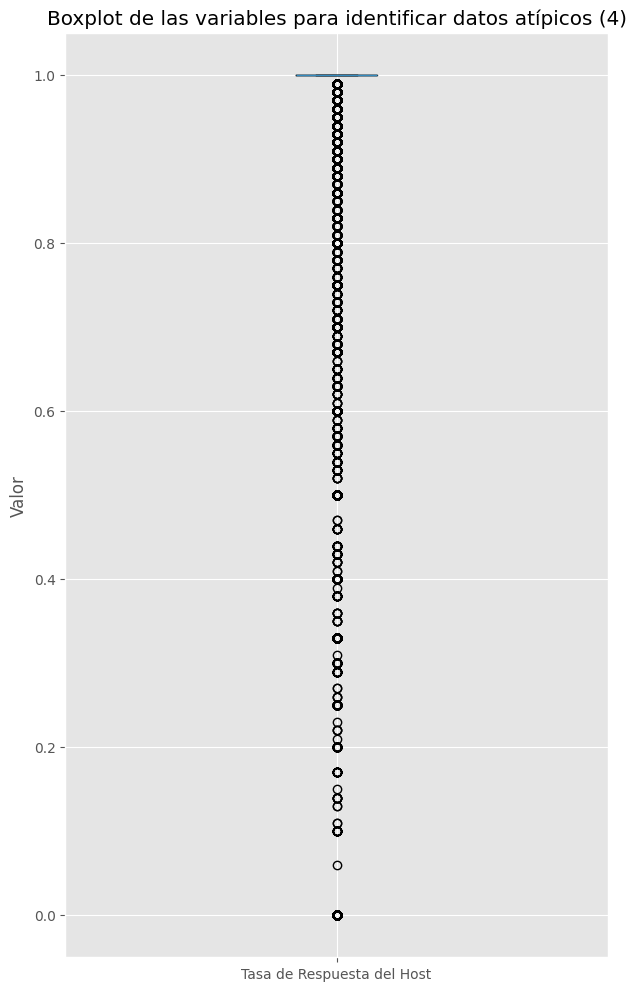

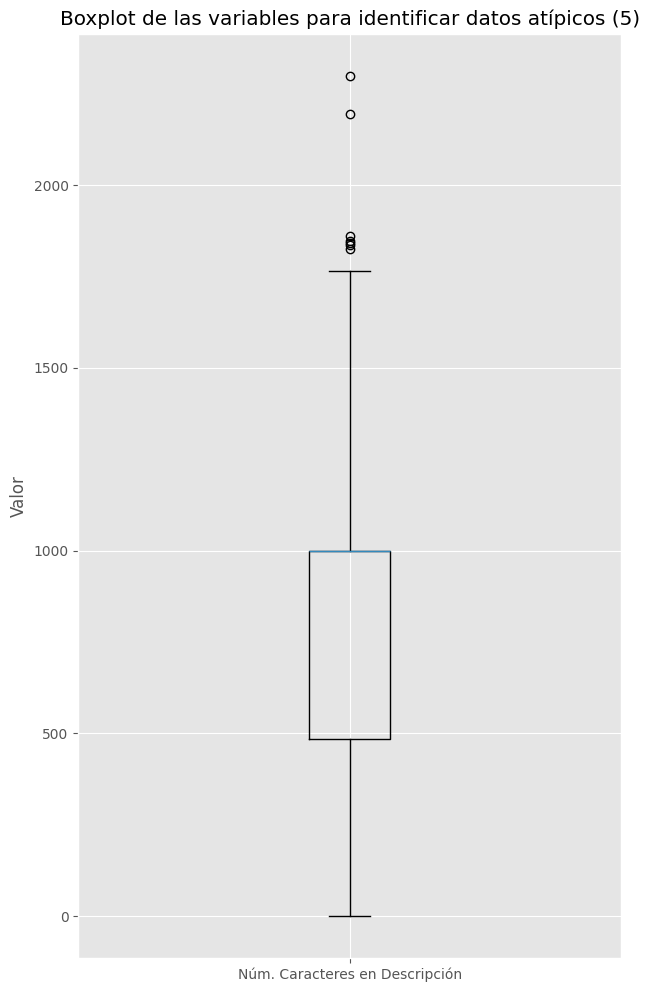

In [ ]:
dfNumNoBinario = dfNum.drop(columns=['Tarifa por Limpieza','Reservable al Instante','Host tiene Foto de Perfil','Identidad Verificada del Host'])
plt.figure(figsize=(11.5,12))
plt.boxplot(dfNumNoBinario[['Puntaje Promedio de Reseñas','Núm. Caracteres en Nombre','Número de Amenidades']])
plt.xticks([1,2,3],['Puntaje Promedio de Reseñas','Núm. Caracteres en Nombre','Número de Amenidades'])
plt.ylabel('Valor')
plt.title('Boxplot de las variables para identificar datos atípicos (1)')
plt.show()

plt.figure(figsize=(14,12))
plt.boxplot(dfNumNoBinario[['Habitaciones (cantidad)','Camas (cantidad)','Baños (cantidad)','Capacidad de Alojamiento']])
plt.xticks([1,2,3,4],['Habitaciones','Camas','Baños','Capacidad de Alojamiento'])
plt.ylabel('Valor')
plt.title('Boxplot de las variables para identificar datos atípicos (2)')
plt.show()

plt.figure(figsize=(7,12))
plt.boxplot(dfNumNoBinario['Número de Reseñas'])
plt.xticks([1],['Número de Reseñas'])
plt.ylabel('Valor')
plt.title('Boxplot de las variables para identificar datos atípicos (3)')
plt.show()

plt.figure(figsize=(7,12))
plt.boxplot(dfNumNoBinario['Tasa de Respuesta del Host'])
plt.xticks([1],['Tasa de Respuesta del Host'])
plt.ylabel('Valor')
plt.title('Boxplot de las variables para identificar datos atípicos (4)')
plt.show()

plt.figure(figsize=(7,12))
plt.boxplot(dfNumNoBinario['Núm. Caracteres en Descripción'])
plt.xticks([1],['Núm. Caracteres en Descripción'])
plt.ylabel('Valor')
plt.title('Boxplot de las variables para identificar datos atípicos (5)')
plt.show()

In [ ]:
# == Eliminar valores atípicosss
for i in dfNum.drop(columns=['Reservable al Instante','Host tiene Foto de Perfil',
                             'Identidad Verificada del Host','Tarifa por Limpieza']).columns:
  std = dfNum[i].std() #desviación estándar
  print(f"{i}: {std:4f}")
  for k in range (1,4):
    sigmaa = dfNum[i].mean() + (std * k) #media + desviaci+on por i
    sigmab = dfNum[i].mean() - (std * k) #media - desviación por i
    print(f"std no° {k}: {sigmaa:4f} - {sigmab:4f}")
    datosSigma = 0

    for j in dfNum[i]:
      if j <= sigmaa and j >= sigmab: #si está dentro del rango,
        datosSigma += 1 #se suma 1
      else:
        if k == 3:
          dfNum.drop(dfNum[i][dfNum[i] > sigmaa].index, inplace=True) # se buscan los valores mayores/menores a sigma(a/b), el index los localiza
          dfNum.drop(dfNum[i][dfNum[i] < sigmab].index, inplace=True) # luego dropea todos los valores que no están en 2 desviaciones

    porceSigma = (datosSigma/len(dfNum[i]))*100 #porcentaje de datos
    print(f"Representa el {porceSigma:.2f}% de los datos")

    print()
  print()

Precio (logaritmo): 0.717394
std no° 1: 5.499463 - 4.064675
Representa el 70.03% de los datos

std no° 2: 6.216857 - 3.347282
Representa el 95.72% de los datos

std no° 3: 6.934250 - 2.629888
Representa el 100.00% de los datos


Capacidad de Alojamiento: 2.105931
std no° 1: 5.232398 - 1.020537
Representa el 74.75% de los datos

std no° 2: 7.338329 - -1.085394
Representa el 95.41% de los datos

std no° 3: 9.444260 - -3.191324
Representa el 100.00% de los datos


Habitaciones (cantidad): 0.733864
std no° 1: 1.940774 - 0.473045
Representa el 68.83% de los datos

std no° 2: 2.674638 - -0.260819
Representa el 93.46% de los datos

std no° 3: 3.408502 - -0.994683
Representa el 100.00% de los datos


Camas (cantidad): 0.944168
std no° 1: 2.519606 - 0.631270
Representa el 86.44% de los datos

std no° 2: 3.463774 - -0.312897
Representa el 95.18% de los datos

std no° 3: 4.407942 - -1.257065
Representa el 100.00% de los datos


Baños (cantidad): 0.446085
std no° 1: 1.616564 - 0.724395
Representa 

In [ ]:
dfNum

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
1,4.828314,6,2.0,4.0,1.0,5,100.0,3,1.0,0.0,1.0,1.0,1.00,26,1001.0,43.0
2,5.010635,2,1.0,1.0,1.0,0,96.0,2,0.0,0.0,1.0,0.0,1.00,21,195.0,31.0
4,4.955827,2,1.0,1.0,1.0,2,100.0,3,1.0,0.0,1.0,1.0,1.00,7,999.0,50.0
5,3.828641,2,1.0,1.0,1.0,0,96.0,3,1.0,0.0,1.0,0.0,0.83,15,524.0,43.0
6,4.007333,2,1.0,1.0,1.0,34,88.0,3,1.0,1.0,1.0,1.0,1.00,22,999.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74104,3.806662,2,1.0,1.0,1.0,2,100.0,2,1.0,0.0,1.0,0.0,1.00,15,230.0,30.0
74105,3.401197,1,1.0,1.0,1.0,0,96.0,2,0.0,1.0,1.0,1.0,1.00,8,328.0,35.0
74107,3.912023,2,1.0,1.0,1.0,0,96.0,2,0.0,0.0,1.0,1.0,1.00,16,999.0,35.0
74109,4.941642,3,1.0,2.0,1.0,8,98.0,1,1.0,0.0,1.0,1.0,1.00,32,1000.0,32.0


In [ ]:
dfNum.describe()

,Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Camas (cantidad),Baños (cantidad),Número de Reseñas,Puntaje Promedio de Reseñas,Póliza de Cancelación,Tarifa por Limpieza,Reservable al Instante,Host tiene Foto de Perfil,Identidad Verificada del Host,Tasa de Respuesta del Host,Número de Amenidades,Núm. Caracteres en Descripción,Núm. Caracteres en Nombre
count,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000,63708.00000,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000,63708.000000
mean,4.721152,2.819834,1.142808,1.500879,1.143216,17.192079,95.134897,2.161063,0.73118,0.258680,0.997096,0.673966,0.978285,17.142478,760.920528,34.917310
std,0.645756,1.521896,0.631262,0.780439,0.358774,25.957308,4.907909,0.816852,0.44335,0.437913,0.053810,0.468764,0.067244,6.220727,317.045355,9.297865
min,2.639057,1.000000,0.000000,0.000000,0.000000,0.000000,74.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.530000,1.000000,1.000000,7.000000
25%,4.248495,2.000000,1.000000,1.000000,1.000000,1.000000,93.000000,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,13.000000,479.000000,30.000000
50%,4.682131,2.000000,1.000000,1.000000,1.000000,6.000000,96.000000,2.000000,1.00000,0.000000,1.000000,1.000000,1.000000,17.000000,999.000000,34.000000
75%,5.164786,4.000000,1.000000,2.000000,1.000000,22.000000,99.000000,3.000000,1.00000,1.000000,1.000000,1.000000,1.000000,21.000000,1000.000000,42.000000
max,6.932448,9.000000,3.000000,4.000000,2.500000,135.000000,100.000000,4.000000,1.00000,1.000000,1.000000,1.000000,1.000000,37.000000,1695.000000,63.000000


In [ ]:
dfNum.dropna(inplace=True)
dfNum.isnull().sum()

,0
Precio (logaritmo),0
Capacidad de Alojamiento,0
Habitaciones (cantidad),0
Camas (cantidad),0
Baños (cantidad),0
Número de Reseñas,0
Puntaje Promedio de Reseñas,0
Póliza de Cancelación,0
Tarifa por Limpieza,0
Reservable al Instante,0


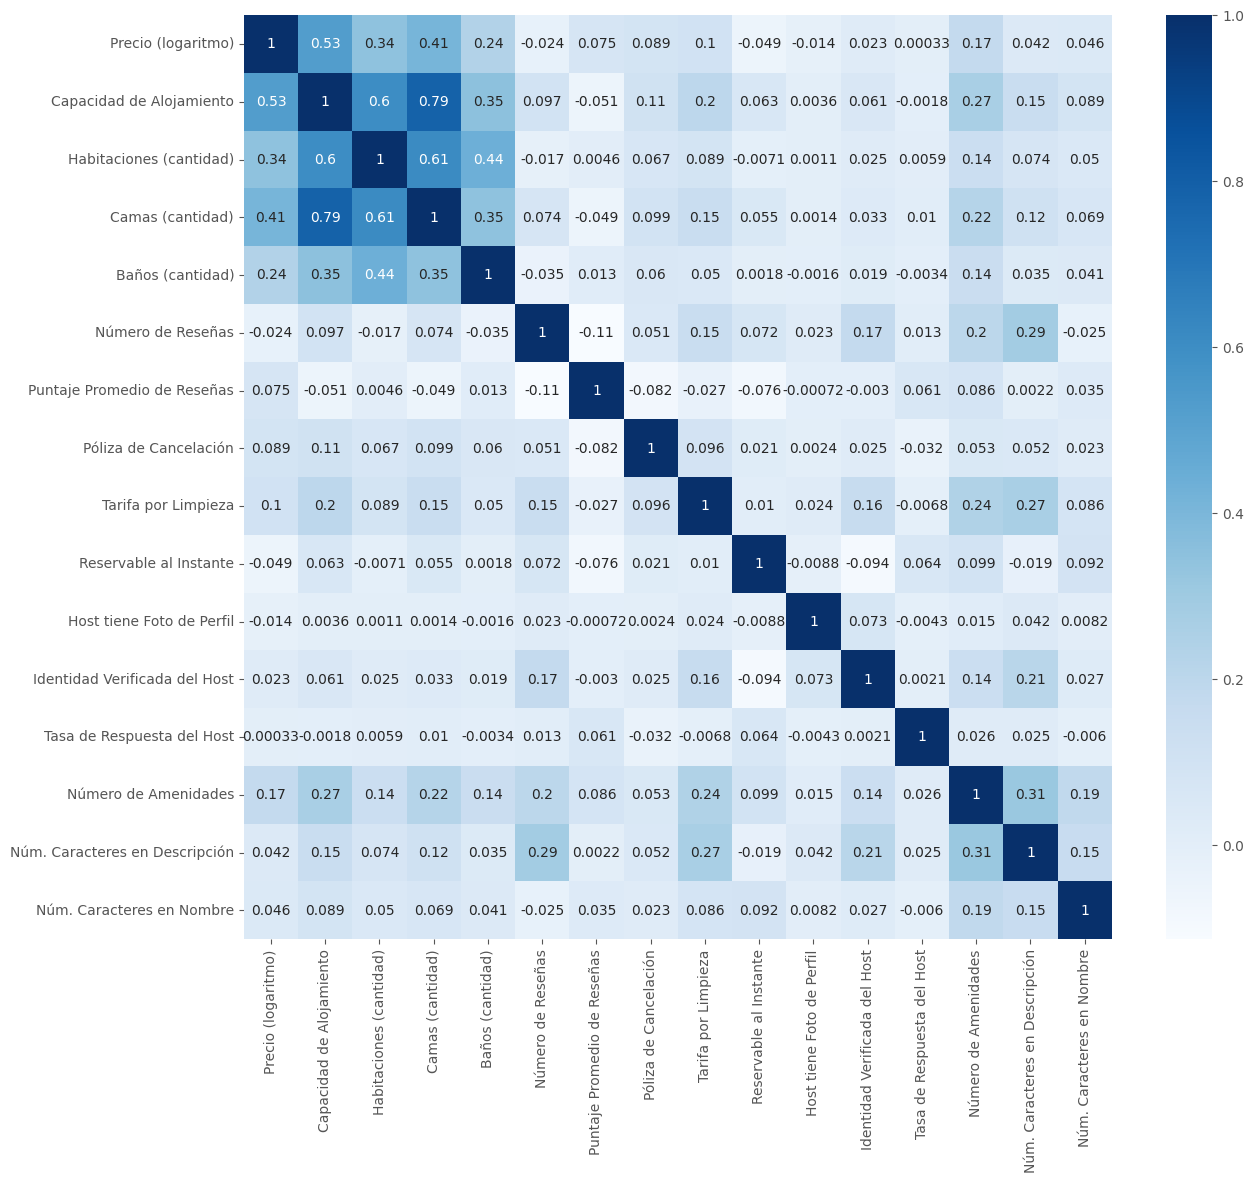

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(dfNum.corr(method= "pearson"), annot=True, cmap='Blues')
plt.show()

In [ ]:
def tidy_corr_matrix (corr_matmats):
  corr_matmats = corr_matmats.stack().reset_index() #recibe matriz desordenada
  corr_matmats.columns = ['variable_1','variable_2','r'] #columnas asigna
  corr_matmats = corr_matmats.loc[corr_matmats['variable_1'] != corr_matmats['variable_2'],:].reset_index(drop=True) #Revisa que las variables sean distintas
  corr_matmats['abs_r'] = np.abs(corr_matmats['r']) #absoluto
  corr_matmats = corr_matmats.sort_values('abs_r', ascending=False) #las reordena y eso

  return corr_matmats #ordena de mayor a menor

corr_matrix = dfNum.corr(method='pearson')
display(tidy_corr_matrix(corr_matrix).T)

,46,17,47,32,16,31,0,15,33,62,...,69,154,153,54,39,152,156,99,11,180
variable_1,Camas (cantidad),Capacidad de Alojamiento,Camas (cantidad),Habitaciones (cantidad),Capacidad de Alojamiento,Habitaciones (cantidad),Precio (logaritmo),Capacidad de Alojamiento,Habitaciones (cantidad),Baños (cantidad),...,Baños (cantidad),Host tiene Foto de Perfil,Host tiene Foto de Perfil,Camas (cantidad),Habitaciones (cantidad),Host tiene Foto de Perfil,Host tiene Foto de Perfil,Puntaje Promedio de Reseñas,Precio (logaritmo),Tasa de Respuesta del Host
variable_2,Capacidad de Alojamiento,Camas (cantidad),Habitaciones (cantidad),Camas (cantidad),Habitaciones (cantidad),Capacidad de Alojamiento,Capacidad de Alojamiento,Precio (logaritmo),Baños (cantidad),Habitaciones (cantidad),...,Host tiene Foto de Perfil,Baños (cantidad),Camas (cantidad),Host tiene Foto de Perfil,Host tiene Foto de Perfil,Habitaciones (cantidad),Puntaje Promedio de Reseñas,Host tiene Foto de Perfil,Tasa de Respuesta del Host,Precio (logaritmo)
r,0.785355,0.785355,0.612184,0.612184,0.604241,0.604241,0.529469,0.529469,0.436779,0.436779,...,-0.00163,-0.00163,0.001369,0.001369,0.001118,0.001118,-0.000716,-0.000716,0.000326,0.000326
abs_r,0.785355,0.785355,0.612184,0.612184,0.604241,0.604241,0.529469,0.529469,0.436779,0.436779,...,0.00163,0.00163,0.001369,0.001369,0.001118,0.001118,0.000716,0.000716,0.000326,0.000326


# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Selección de variables

**Según la correlación, la única variable relevante**

In [ ]:
#Definir variables:

X = dfNum['Capacidad de Alojamiento']
y = dfNum['Precio (logaritmo)']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1,1),
    test_size=0.2,
    random_state=413,
    shuffle = True)

In [ ]:
# == MODELO OLS
X_train = sm.add_constant(X_train)
modelo_OLS = sm.OLS(endog =y_train,exog =X_train).fit()
print(modelo_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                 1.979e+04
Date:                Wed, 14 May 2025   Prob (F-statistic):               0.00
Time:                        14:28:34   Log-Likelihood:                -41713.
No. Observations:               50966   AIC:                         8.343e+04
Df Residuals:                   50964   BIC:                         8.345e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
reg = LinearRegression().fit(X_train, y_train)
print("\nCoeficiente de determinación: ",  f"{(reg.score(X_train, y_train)):.3f}")
print(f"El valor de R nos indica que el modelo explica correctamente el {((reg.score(X_train, y_train))*100):.1f}% de los datos.\n")
print("La ecuación general del modelo es:")

print("Precio (logarítmico) = ", end="")
for i in (reg.coef_[0][1:]):
    print(f"{i:.4f} x + ", end="")
print(f"{reg.intercept_[0]:.4f}")


Coeficiente de determinación:  0.280
El valor de R nos indica que el modelo explica correctamente el 28.0% de los datos.

La ecuación general del modelo es:
Precio (logarítmico) = 0.2246 x + 4.0869


In [ ]:
#Predicciones Y Error (Modelo OLS)
X_Test_DF = pd.DataFrame(X_test, columns= ['Capacidad de Alojamiento'])
X_Test_DF = sm.add_constant(X_Test_DF, prepend=True)
Prediccion = modelo_OLS.predict(X_Test_DF)

Resultados = pd.DataFrame({
    'Precio Observado' : y_test.flatten(),
    'Prediccion' : Prediccion,
    'Delta' : abs(y_test.flatten() - Prediccion)
})
print(Resultados.head(10))

X_test = sm.add_constant(X_test, prepend = True)
rmse = mean_squared_error(
    y_true = y_test,
    y_pred = Prediccion
)

print(f"\nEl error medio es: {np.sqrt(rmse):.2f}")

       Precio Observado  Prediccion     Delta
42425          5.293305    4.536154  0.757151
39503          5.003946    4.536154  0.467792
23171          5.247024    4.985428  0.261596
21374          4.700480    4.760791  0.060311
32563          4.174387    4.311517  0.137130
24743          4.025352    4.536154  0.510802
15865          3.555348    4.311517  0.756169
50609          5.521461    4.985428  0.536033
64916          4.691348    4.536154  0.155194
10204          3.637586    4.536154  0.898568

El error medio es: 0.54


**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Variables con al menos un poco de correlación**

In [ ]:
from sklearn.preprocessing import StandardScaler
#Definir variables:
X = dfNum.drop(columns=['Precio (logaritmo)','Número de Reseñas',
                        'Núm. Caracteres en Nombre','Núm. Caracteres en Descripción',
                        'Identidad Verificada del Host','Host tiene Foto de Perfil',
                        #'Puntaje Promedio de Reseñas','Tasa de Respuesta del Host',
                        'Tarifa por Limpieza',
                        'Baños (cantidad)','Camas (cantidad)','Habitaciones (cantidad)'])
#Todas las que son MUY bajas y generan multicolinealidad
y = dfNum['Precio (logaritmo)']


<Axes: >

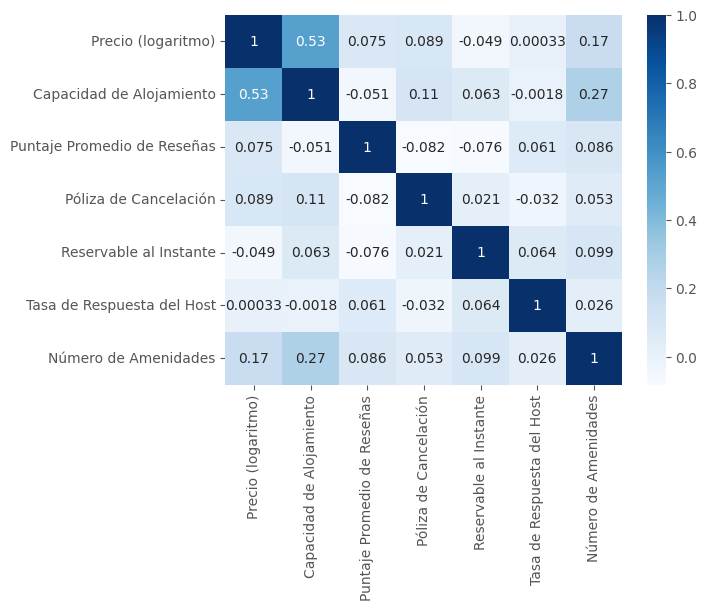

In [ ]:
sns.heatmap(dfNum.drop(columns=['Número de Reseñas',
                        'Núm. Caracteres en Nombre','Núm. Caracteres en Descripción',
                        'Identidad Verificada del Host','Host tiene Foto de Perfil',
                        'Tarifa por Limpieza',
                        'Baños (cantidad)','Camas (cantidad)','Camas (cantidad)','Habitaciones (cantidad)',]).corr(method= "pearson"), annot=True,cmap='Blues')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1,1),
    test_size=0.2,
    random_state=413,
    shuffle = True)

In [ ]:
# == MODELO OLS
X_train = sm.add_constant(X_train)
modelo_OLS = sm.OLS(endog =y_train,exog =X_train).fit()
print(modelo_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     3596.
Date:                Wed, 14 May 2025   Prob (F-statistic):               0.00
Time:                        14:28:35   Log-Likelihood:                -41076.
No. Observations:               50966   AIC:                         8.217e+04
Df Residuals:                   50959   BIC:                         8.223e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
reg = LinearRegression().fit(X_train, y_train)
print("\nCoeficiente de determinación: ",  f"{(reg.score(X_train, y_train)):.3f}")
print(f"El valor de R nos indica que el modelo explica correctamente el {((reg.score(X_train, y_train))*100):.1f}% de los datos.\n")
print("La ecuación general del modelo es:")

print("Precio (logarítmico) = ", end="")
for i in (reg.coef_[0][1:]):
    print(f"{i:.4f} x + ", end="")
print(f"{reg.intercept_[0]:.4f}")


Coeficiente de determinación:  0.297
El valor de R nos indica que el modelo explica correctamente el 29.7% de los datos.

La ecuación general del modelo es:
Precio (logarítmico) = 0.2241 x + 0.0128 x + 0.0315 x + -0.1100 x + -0.0018 x + 0.0026 x + 2.7856


In [ ]:
#Predicciones Y Error (Modelo OLS)
columnas = dfNum.drop(columns=['Precio (logaritmo)','Número de Reseñas',
                        'Núm. Caracteres en Nombre','Núm. Caracteres en Descripción',
                        'Identidad Verificada del Host','Host tiene Foto de Perfil',
                               'Tarifa por Limpieza',
                        'Baños (cantidad)','Camas (cantidad)','Habitaciones (cantidad)']).columns
X_Test_DF = pd.DataFrame(X_test, columns= columnas)
X_Test_DF = sm.add_constant(X_Test_DF, prepend=True)
Prediccion = modelo_OLS.predict(X_Test_DF)

Resultados = pd.DataFrame({
    'Precio Observado' : y_test.flatten(),
    'Prediccion' : Prediccion,
    'Delta' : abs(y_test.flatten() - Prediccion)
})

ErrorMean = Resultados['Delta'].mean()
print(f"El error medio es: {ErrorMean:.2f}")

print(Resultados.head(10))

X_test = sm.add_constant(X_test, prepend = True)
rmse = mean_squared_error(
    y_true = y_test,
    y_pred = Prediccion
)

print(f"\nEl error medio es: {np.sqrt(rmse):.2f}")

El error medio es: 0.42
       Precio Observado  Prediccion     Delta
42425          5.293305    4.615254  0.678050
39503          5.003946    4.541593  0.462353
23171          5.247024    4.747864  0.499160
21374          4.700480    4.830755  0.130275
32563          4.174387    4.338219  0.163832
24743          4.025352    4.596952  0.571600
15865          3.555348    4.297098  0.741750
50609          5.521461    4.991381  0.530079
64916          4.691348    4.598965  0.092383
10204          3.637586    4.460566  0.822980

El error medio es: 0.54


# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Comparación de Modelos

**Modelo Ridge**

In [ ]:
#Normalizar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.fit_transform(X_test)

In [ ]:
'''MODELO RIDGE'''
modelo = RidgeCV(
            alphas          = np.logspace(-3, 10, 200),
            fit_intercept   = True,
            store_cv_values = True
         )

modeloRidge = modelo.fit(X = X_train, y = y_train)

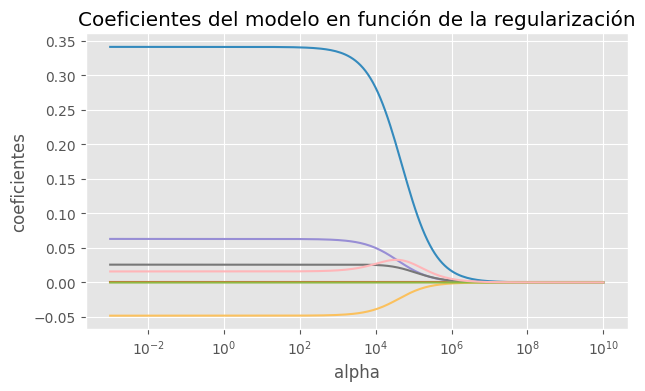

In [ ]:
# Evolución de los coeficientes en función de alpha
alphas = modeloRidge.alphas
coefs = []

for alpha in alphas:
    modeloRidge_temp = Ridge(alpha=alpha, fit_intercept=False)
    modeloRidge_temp.fit(X_train, y_train)
    coefs.append(modeloRidge_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');
plt.axis('tight')
plt.show()

In [ ]:
# Predicciones test
predicciones = modeloRidge.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]


Resultados = pd.DataFrame({
    'Precio Observado' : y_test.flatten(),
    'Prediccion' : predicciones,
    'Delta' : abs(y_test.flatten() - predicciones)
})
print(Resultados.head(10))
#

# Error de test del modelo
rmse_ridge = np.sqrt(mean_squared_error(
                y_true  = y_test,
                y_pred  = predicciones
             ))
print("")
print(f"El error (rmse) de test es: {np.sqrt(rmse_ridge):.2f}")

   Precio Observado  Prediccion     Delta
0          5.293305    4.611757  0.681547
1          5.003946    4.538016  0.465930
2          5.247024    4.744354  0.502670
3          4.700480    4.826713  0.126233
4          4.174387    4.334726  0.160339
5          4.025352    4.593417  0.568065
6          3.555348    4.293660  0.738312
7          5.521461    4.987084  0.534376
8          4.691348    4.595212  0.096136
9          3.637586    4.457625  0.820039

El error (rmse) de test es: 0.73


**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Modelo Lasso**

In [ ]:
'''MODELO LASSO'''

modelo = LassoCV(
            alphas          = np.logspace(-10, 3, 200),
            cv              = 10
         )
modeloLasso = modelo.fit(X = X_train, y = y_train)

In [ ]:
# Evolución de los coeficientes en función de alpha
alphas = modeloLasso.alphas_
coefs = []

for alpha in alphas:
    modeloLasso_temp = Lasso(alpha=alpha, fit_intercept=False)
    modeloLasso_temp.fit(X_train, y_train)
    coefs.append(modeloLasso_temp.coef_.flatten())

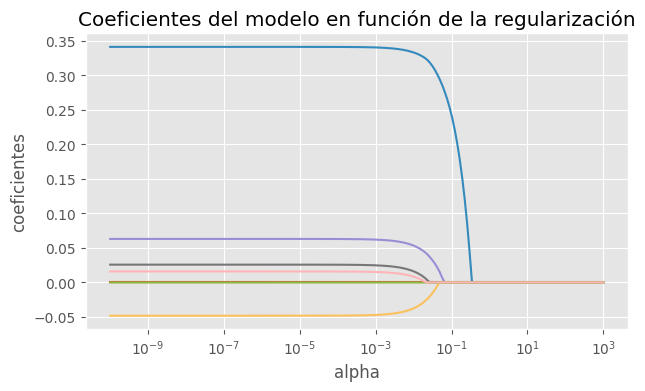

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.axis('tight')
plt.show()

In [ ]:
# Predicciones test
predicciones = modeloLasso.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]

Resultados = pd.DataFrame({
    'Precio Observado' : y_test.flatten(),
    'Prediccion' : predicciones,
    'Delta' : abs(y_test.flatten() - predicciones)
})
print(Resultados.head(10))
#

# Error de test del modelo
rmse_lasso = np.sqrt(mean_squared_error(
                y_true  = y_test,
                y_pred  = predicciones
             ))
print("")
print(f"El error (rmse) de test es: {np.sqrt(rmse_lasso):.2f}")

   Precio Observado  Prediccion     Delta
0          5.293305    4.609735  0.683570
1          5.003946    4.538411  0.465535
2          5.247024    4.746429  0.500595
3          4.700480    4.826199  0.125718
4          4.174387    4.336486  0.162099
5          4.025352    4.592136  0.566784
6          3.555348    4.295646  0.740298
7          5.521461    4.986182  0.535279
8          4.691348    4.595389  0.095959
9          3.637586    4.459482  0.821896

El error (rmse) de test es: 0.73


**--------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Modelo ElasticNet**

In [ ]:
'''MODELO ELASTICNET'''
modelo = ElasticNetCV(
            alphas          = np.logspace(-10, 3, 200),
            fit_intercept   = True,
         )

modeloElasticNet = modelo.fit(X = X_train, y = y_train)

In [ ]:
# Evolución de los coeficientes en función de alpha
alphas = modeloElasticNet.alphas_
coefs = []

for alpha in alphas:
    modeloElasticNet_temp = Lasso(alpha=alpha, fit_intercept=False)
    modeloElasticNet_temp.fit(X_train, y_train)
    coefs.append(modeloElasticNet_temp.coef_.flatten())

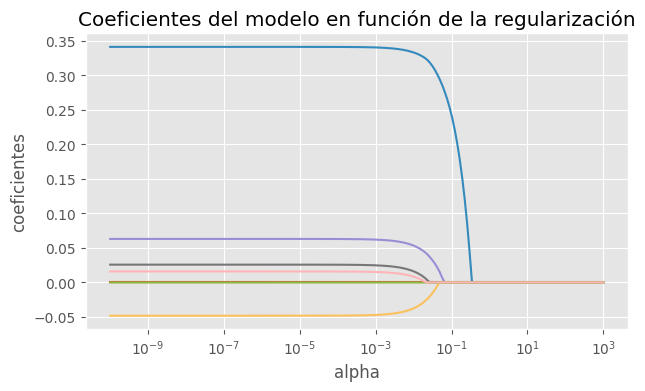

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
#ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.axis('tight')
plt.show()

In [ ]:
# Predicciones test
predicciones = modeloElasticNet.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]

Resultados = pd.DataFrame({
    'Precio Observado' : y_test.flatten(),
    'Prediccion' : predicciones,
    'Delta' : abs(y_test.flatten() - predicciones)
})
print(Resultados.head(10))
#

# Error de test del modelo
rmse_ElasticNet = np.sqrt(mean_squared_error(
                y_true  = y_test,
                y_pred  = predicciones
             ))
print("")
print(f"El error (rmse) de test es: {np.sqrt(rmse_ElasticNet):.2f}")

   Precio Observado  Prediccion     Delta
0          5.293305    4.610050  0.683255
1          5.003946    4.538566  0.465380
2          5.247024    4.746345  0.500679
3          4.700480    4.826066  0.125586
4          4.174387    4.336462  0.162074
5          4.025352    4.592411  0.567059
6          3.555348    4.295695  0.740347
7          5.521461    4.986038  0.535423
8          4.691348    4.595345  0.096002
9          3.637586    4.459528  0.821942

El error (rmse) de test es: 0.73


# **--------------------------------------------------------------------------------------------------------------------------------------------------------------**